# Hippocampus ↔ Amygdala — HFA Communication-Subspace Analysis (CSA)

Pipeline implementing the Binish et al. PFC→M1 CSA framework on Sternberg-CAT microwire LFP.
Source = hippocampus, target = amygdala (swappable via `CONFIG['flip_direction']`).

**Build order:** sections 1–5 are runnable; sections 6–12 are scaffolded with TODO + decision-point notes
and are intentionally left for a second pass *after* the HFA extraction has been QC'd.

**Decision points flagged in-place** (look for `# DECISION:` comments). Defaults shown were picked
as reasonable starting points and should be reviewed before treating any output as final.

## 1. Setup & Configuration

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import signal as scisig
from scipy import stats as scistats
from scipy.signal import butter, filtfilt, iirnotch, hilbert, detrend

from pynwb import NWBHDF5IO

from nwb_analysis import (
    get_subject_files,
    load_nwb_file,
    load_lfp_safe,
    extract_region_channels,
    group_trials_by_load,
)
from nwb_analysis.config import BRAIN_REGIONS

plt.rcParams.update({'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': 0.3})
warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=UserWarning, module="pynwb")

RNG = np.random.default_rng(20260506)  # global seeded RNG; pass explicitly to subroutines

In [9]:
# === CONFIG ===
# All knobs in one place. Region/source/target are swappable: flip `flip_direction`
# to run amyg→hipp without changing the rest of the notebook.

PROJECT_ROOT = Path('.').resolve()
DATA_DIR = PROJECT_ROOT / '000673'
OUT_DIR = PROJECT_ROOT / 'outputs' / 'hipp_amyg_HFA_CSA'
OUT_DIR.mkdir(parents=True, exist_ok=True)

CONFIG = {
    # --- I/O ---
    'data_dir': DATA_DIR,
    'out_dir': OUT_DIR,
    'random_seed': 20260506,

    # --- Source / target regions ---
    'source_region': 'Hippocampus',   # CONFIG['source_region'] supplies X (predictor) in RRR
    'target_region': 'Amygdala',      # CONFIG['target_region'] supplies Y (predicted) in RRR
    'flip_direction': False,          # if True, swap source/target (run amyg → hipp)

    # --- Coverage filtering ---
    'min_chans_per_region': 8,        # DECISION: threshold for session inclusion. 8 = configurable starting point.

    # --- Line noise ---
    'line_freq_hz': 60.0,             # DECISION: Cedars-Sinai recordings → 60 Hz. Switch to 50 Hz if any sessions are EU.
    'line_harmonics': (60.0, 120.0),  # 180 Hz is above Nyquist at 400 Hz fs.
    'notch_q': 30.0,                  # narrow notch (~2 Hz wide at 60 Hz) so HFA isn't gutted.

    # --- Local referencing ---
    # DECISION: whether the NWB LFP is already locally referenced. Inspect manually first;
    # set to True to skip re-referencing, or False to apply bundle CAR (mean within bundle, subtract).
    # The Rutishauser group typically references each microwire to a reference wire in the same
    # 8-wire bundle. We'll detect bundles via electrode 'group_name' / 'group' field; if no bundle
    # info is available, we fall back to per-region CAR with a printed warning.
    'assume_already_referenced': True,
    'bundle_field_candidates': ['group_name', 'group', 'bundle'],  # checked in order

    # --- HFA extraction (Binish et al. methods) ---
    # "To extract the HFA timeseries, we first bandpass-filtered the cleaned data epochs into
    #  seven nonoverlapping 10 Hz wide bins (±5 Hz) with center bins spaced linearly between
    #  75 Hz and 145 Hz."
    'hfa_subband_center_lo': 8.0,      # lowest sub-band center
    'hfa_subband_center_hi': 8.0,     # highest sub-band center
    'hfa_subband_half_width_hz': 4.0,   # ±5 Hz → 10 Hz wide bins
    'hfa_use_narrow': False,            # DECISION: if True, use 75–105 Hz center range to mitigate spike contamination
    'hfa_subband_center_lo_narrow': 75.0,
    'hfa_subband_center_hi_narrow': 105.0,
    'hfa_n_subbands': 1,                # 7 sub-bands
    'hfa_filter_order': 4,              # Butterworth bandpass order (applied with filtfilt)
    'hfa_baseline_window': (-1.0, 0.0), # baseline relative to encoding-onset (s); used for z-scoring
    'hfa_baseline_bootstrap_iters': 1000,  # resamples for baseline μ, σ

    # --- Epoching ---
    # DECISION: which event to lock to. Default = first encoding onset (cleanest analog
    # to Binish et al. target onset). Other options below are kept so swapping is one-line.
    'lock_event': 'encoding1',          # one of: 'encoding1', 'maintenance', 'probe'
    'epoch_window_encoding': (0.0, 2.0),     # s relative to first encoding onset (encoding1 lock)
    'epoch_window_maintenance': (0.0, 2.5),  # s relative to maintenance (delay) onset
    'epoch_window_probe': (-0.5, 1.5),       # s relative to probe onset
    'use_only_correct': True,           # DECISION: drop incorrect trials. Conservative default; could relax.
    'trial_grouping': 'category',       # 'load' or 'category' (1st-stim category, derived from PicIDs_Encoding1 // 100)
    'category_keep': (1, 2, 3, 4, 5),   # which 1st-stim categories to include when grouping by category

    # --- Artifact rejection ---
    'artifact_amp_z': 6.0,              # channel-level: |z| of per-channel std exceeding this → reject
    'artifact_var_z': 6.0,              # channel-level: same for variance
    'artifact_trial_p2p_uV': 3000.0,    # per-trial peak-to-peak rejection threshold

    # --- RRR / CSA (sections 7–8; not yet wired up) ---
    'rrr_n_chans_subsample': 10,        # DECISION: matches Binish et al. starting point
    'rrr_bootstrap_iters': 1000,
    'rrr_cv_folds': 10,
    'rrr_alpha_grid': np.logspace(-3, 3, 13),
    'rrr_rank_grid': None,              # set to range(1, n_chans+1) at runtime
    'rrr_condition_split': 'load',      # DECISION: 'load' (1 vs 3), 'match' (in vs out probe), or 'category'
}

# Apply direction flip
if CONFIG['flip_direction']:
    CONFIG['source_region'], CONFIG['target_region'] = CONFIG['target_region'], CONFIG['source_region']

# Resolve sub-band centers and edges from the active center range.
if CONFIG['hfa_use_narrow']:
    _c_lo, _c_hi = CONFIG['hfa_subband_center_lo_narrow'], CONFIG['hfa_subband_center_hi_narrow']
else:
    _c_lo, _c_hi = CONFIG['hfa_subband_center_lo'], CONFIG['hfa_subband_center_hi']

CONFIG['hfa_subband_centers'] = np.linspace(_c_lo, _c_hi, CONFIG['hfa_n_subbands'])
_hw = CONFIG['hfa_subband_half_width_hz']
CONFIG['hfa_subband_edges'] = [(c - _hw, c + _hw) for c in CONFIG['hfa_subband_centers']]
# Outer band span = lowest sub-band low edge → highest sub-band high edge
CONFIG['hfa_band_active'] = (CONFIG['hfa_subband_edges'][0][0], CONFIG['hfa_subband_edges'][-1][1])

# Resolve active epoch window
_lock_to_window = {
    'encoding1': CONFIG['epoch_window_encoding'],
    'maintenance': CONFIG['epoch_window_maintenance'],
    'probe': CONFIG['epoch_window_probe'],
}
CONFIG['epoch_window_active'] = _lock_to_window[CONFIG['lock_event']]

print(f"Source → Target: {CONFIG['source_region']} → {CONFIG['target_region']}")
print(
    f"HFA: bandpass-filtered into {CONFIG['hfa_n_subbands']} non-overlapping 10 Hz wide bins "
    f"(±{_hw:.0f} Hz),\n"
    f"     centers spaced linearly between {_c_lo:.0f} Hz and {_c_hi:.0f} Hz "
    f"→ centers = [{', '.join(f'{c:.2f}' for c in CONFIG['hfa_subband_centers'])}] Hz"
)
print(f"     outer band span: {CONFIG['hfa_band_active'][0]:.0f}–{CONFIG['hfa_band_active'][1]:.0f} Hz")
print(f"Lock event: {CONFIG['lock_event']}, epoch window: {CONFIG['epoch_window_active']} s")
print(f"Output dir: {CONFIG['out_dir']}")

Source → Target: Hippocampus → Amygdala
HFA: bandpass-filtered into 1 non-overlapping 10 Hz wide bins (±4 Hz),
     centers spaced linearly between 8 Hz and 8 Hz → centers = [8.00] Hz
     outer band span: 4–12 Hz
Lock event: encoding1, epoch window: (0.0, 2.0) s
Output dir: E:\SBCAT\outputs\hipp_amyg_HFA_CSA


## 2. Data Loading — Session Inventory

Walks every NWB file under `DATA_DIR`, opens it lazily (closes immediately), and records counts of channels in each region by hemisphere plus number of trials. We then filter by the dual-coverage threshold from CONFIG.

In [3]:
def hemisphere_from_location(loc: str) -> str:
    if not isinstance(loc, str):
        return 'unknown'
    if loc.endswith('_left'):
        return 'L'
    if loc.endswith('_right'):
        return 'R'
    return 'unknown'


def build_session_inventory(data_dir: Path, regions=('Hippocampus', 'Amygdala')) -> pd.DataFrame:
    files = get_subject_files(data_dir)
    rows = []
    for f in files:
        try:
            with NWBHDF5IO(str(f), mode='r', load_namespaces=True) as io:
                nwbf = io.read()
                edf = nwbf.electrodes.to_dataframe() if nwbf.electrodes is not None else None
                trials = nwbf.trials.to_dataframe() if nwbf.trials is not None else None
                lfp_rate = float(nwbf.acquisition['LFPs'].rate) if 'LFPs' in nwbf.acquisition else np.nan
                lfp_n_samples = int(nwbf.acquisition['LFPs'].data.shape[0]) if 'LFPs' in nwbf.acquisition else 0
        except Exception as e:
            print(f"  [skip] {f.name}: {e}")
            continue

        if edf is None:
            continue
        region_chans, _ = extract_region_channels(edf)
        hemi = edf['location'].map(hemisphere_from_location) if 'location' in edf.columns else pd.Series(dtype=str)

        row = {
            'subject': f.parent.name,
            'session': f.stem,
            'filepath': f,
            'lfp_fs': lfp_rate,
            'lfp_n_samples': lfp_n_samples,
            'n_trials': 0 if trials is None else len(trials),
        }
        for region in regions:
            chans = region_chans.get(region, [])
            row[f'n_{region.lower()}'] = len(chans)
            if len(chans) and len(hemi):
                hemi_counts = hemi.loc[chans].value_counts()
                row[f'n_{region.lower()}_L'] = int(hemi_counts.get('L', 0))
                row[f'n_{region.lower()}_R'] = int(hemi_counts.get('R', 0))
            else:
                row[f'n_{region.lower()}_L'] = 0
                row[f'n_{region.lower()}_R'] = 0
        rows.append(row)
    return pd.DataFrame(rows)


inventory = build_session_inventory(
    CONFIG['data_dir'],
    regions=(CONFIG['source_region'], CONFIG['target_region']),
)
src_col = f"n_{CONFIG['source_region'].lower()}"
tgt_col = f"n_{CONFIG['target_region'].lower()}"
thr = CONFIG['min_chans_per_region']
inventory['passes_coverage'] = (inventory[src_col] >= thr) & (inventory[tgt_col] >= thr)

print(f"Total sessions found: {len(inventory)}")
print(f"Sessions passing dual-coverage threshold (≥{thr} in each of "
      f"{CONFIG['source_region']} & {CONFIG['target_region']}): {inventory['passes_coverage'].sum()}")
print(f"Subjects passing: {inventory.loc[inventory['passes_coverage'], 'subject'].nunique()}")
inventory.head(10)

Total sessions found: 44
Sessions passing dual-coverage threshold (≥8 in each of Hippocampus & Amygdala): 28
Subjects passing: 21


,subject,session,filepath,lfp_fs,lfp_n_samples,n_trials,n_hippocampus,n_hippocampus_L,n_hippocampus_R,n_amygdala,n_amygdala_L,n_amygdala_R,passes_coverage
0,sub-1,sub-1_ses-1_ecephys+image,E:\SBCAT\000673\sub-1\sub-1_ses-1_ecephys+imag...,400.0,550276,140,14,7,7,15,7,8,True
1,sub-1,sub-1_ses-2_ecephys+image,E:\SBCAT\000673\sub-1\sub-1_ses-2_ecephys+imag...,400.0,521256,140,15,7,8,15,7,8,True
2,sub-10,sub-10_ses-1_ecephys+image,E:\SBCAT\000673\sub-10\sub-10_ses-1_ecephys+im...,400.0,569380,140,8,6,2,5,0,5,False
3,sub-11,sub-11_ses-1_ecephys+image,E:\SBCAT\000673\sub-11\sub-11_ses-1_ecephys+im...,400.0,574744,139,15,8,7,14,7,7,True
4,sub-12,sub-12_ses-1_ecephys+image,E:\SBCAT\000673\sub-12\sub-12_ses-1_ecephys+im...,400.0,556712,140,8,7,1,14,7,7,True
5,sub-12,sub-12_ses-2_ecephys+image,E:\SBCAT\000673\sub-12\sub-12_ses-2_ecephys+im...,400.0,545215,140,8,7,1,8,6,2,True
6,sub-13,sub-13_ses-1_ecephys+image,E:\SBCAT\000673\sub-13\sub-13_ses-1_ecephys+im...,400.0,536108,140,14,7,7,14,7,7,True
7,sub-14,sub-14_ses-1_ecephys+image,E:\SBCAT\000673\sub-14\sub-14_ses-1_ecephys+im...,400.0,579049,140,3,3,0,7,7,0,False
8,sub-15,sub-15_ses-1_ecephys+image,E:\SBCAT\000673\sub-15\sub-15_ses-1_ecephys+im...,400.0,623098,140,14,7,7,15,7,8,True
9,sub-16,sub-16_ses-1_ecephys+image,E:\SBCAT\000673\sub-16\sub-16_ses-1_ecephys+im...,400.0,571330,140,14,7,7,15,8,7,True


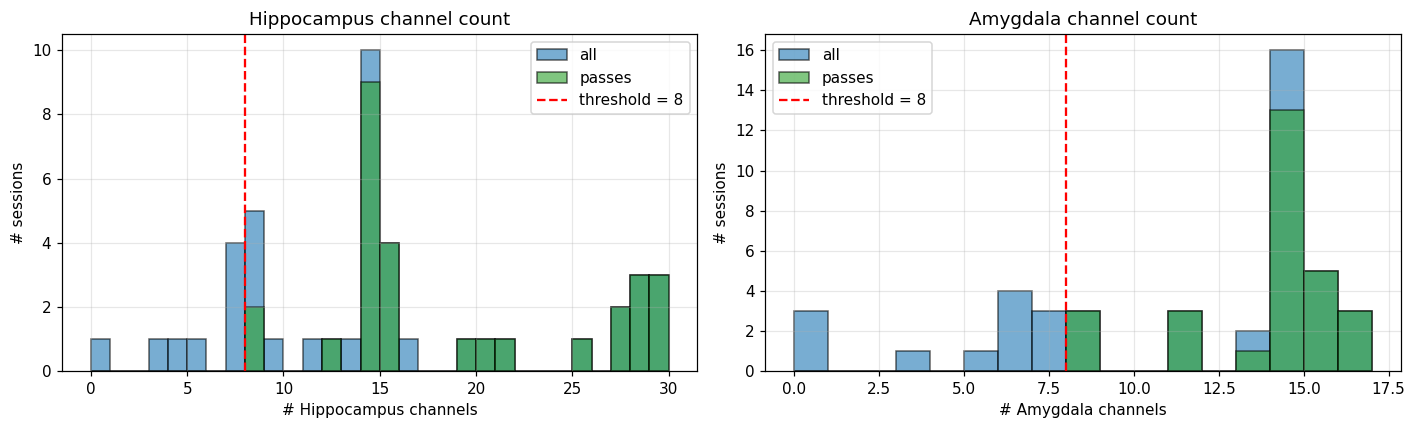


Per-subject session count (passing only):
subject
sub-1     2
sub-11    1
sub-12    2
sub-13    1
sub-15    1
sub-16    1
sub-17    1
sub-19    2
sub-2     1
sub-21    1
sub-22    3
sub-26    2
sub-28    1
sub-29    1
sub-3     1
sub-30    1
sub-31    2
sub-32    1
sub-33    1
sub-4     1
sub-9     1
dtype: int64


In [4]:
passing = inventory[inventory['passes_coverage']].copy()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(inventory[src_col], bins=range(0, inventory[src_col].max() + 2),
             edgecolor='black', alpha=0.6, label='all')
axes[0].hist(passing[src_col], bins=range(0, inventory[src_col].max() + 2),
             edgecolor='black', color='C2', alpha=0.6, label='passes')
axes[0].axvline(thr, color='red', linestyle='--', label=f'threshold = {thr}')
axes[0].set_xlabel(f'# {CONFIG["source_region"]} channels'); axes[0].set_ylabel('# sessions')
axes[0].set_title(f'{CONFIG["source_region"]} channel count'); axes[0].legend()

axes[1].hist(inventory[tgt_col], bins=range(0, inventory[tgt_col].max() + 2),
             edgecolor='black', alpha=0.6, label='all')
axes[1].hist(passing[tgt_col], bins=range(0, inventory[tgt_col].max() + 2),
             edgecolor='black', color='C2', alpha=0.6, label='passes')
axes[1].axvline(thr, color='red', linestyle='--', label=f'threshold = {thr}')
axes[1].set_xlabel(f'# {CONFIG["target_region"]} channels'); axes[1].set_ylabel('# sessions')
axes[1].set_title(f'{CONFIG["target_region"]} channel count'); axes[1].legend()
plt.tight_layout(); plt.show()

print("\nPer-subject session count (passing only):")
print(passing.groupby('subject').size().sort_index())

## 3. Preprocessing per Session

For each candidate session: demean → detrend → notch (60 + 120 Hz) → optional bundle-local re-reference → channel-level artifact rejection.

**DECISION POINT — local referencing:** the Rutishauser group typically references each microwire
to a reference wire within its 8-wire bundle. Inspect one NWB file to verify whether that has
already been done; set `CONFIG['assume_already_referenced'] = True` if so. Otherwise we apply
bundle-CAR (subtract the mean of all wires in the same bundle). If no bundle field is found,
we fall back to **per-region CAR** with a printed warning so it doesn't silently differ from
what the Rutishauser group does.

In [5]:
def make_notch(fs: float, freq: float, q: float = 30.0):
    return iirnotch(w0=freq, Q=q, fs=fs)


def apply_notch_chain(x: np.ndarray, fs: float, harmonics, q: float) -> np.ndarray:
    # x: (T, n_chan); apply notch at each harmonic in series.
    y = x.copy()
    for f0 in harmonics:
        if f0 >= fs / 2:
            continue
        b, a = make_notch(fs, f0, q=q)
        y = filtfilt(b, a, y, axis=0)
    return y


def detect_bundles(electrodes_df: pd.DataFrame, candidate_fields):
    """Return Series mapping channel_idx → bundle_label, or None if no field works."""
    for field in candidate_fields:
        if field not in electrodes_df.columns:
            continue
        labels = electrodes_df[field].astype(str)
        # field is informative only if it has > 1 unique value AND any group has multiple chans
        if labels.nunique() > 1 and (labels.value_counts() > 1).any():
            return labels
    # Fallback: combine 'location' (=anatomical site) with the *position* field if available.
    # The microwire bundles in this dataset are uniquely identified by 'location' (each anat
    # site has its own 8-wire bundle), so per-location grouping is a reasonable bundle proxy
    # when no explicit bundle field exists.
    if 'location' in electrodes_df.columns:
        return electrodes_df['location'].astype(str)
    return None


def bundle_local_reference(lfp: np.ndarray, bundle_labels: pd.Series, channel_indices) -> np.ndarray:
    """Subtract mean within bundle from each channel.

    lfp: (T, n_chan_in_lfp)
    bundle_labels: indexed by *electrode_idx* (matches columns of lfp)
    channel_indices: list of electrode indices to operate on (returns full (T, n_chan) with mods).
    """
    out = lfp.copy()
    sub_labels = bundle_labels.loc[channel_indices]
    for bundle, group in sub_labels.groupby(sub_labels):
        idx = group.index.tolist()
        if len(idx) < 2:
            continue  # 1-channel bundle: nothing to reference against
        bundle_mean = lfp[:, idx].mean(axis=1, keepdims=True)
        out[:, idx] = lfp[:, idx] - bundle_mean
    return out


def detect_artifact_channels(lfp: np.ndarray, channel_indices, amp_z: float, var_z: float):
    """Flag channels whose std/variance is an outlier within the channel set."""
    sub = lfp[:, channel_indices]
    chan_std = sub.std(axis=0)
    chan_var = sub.var(axis=0)
    # robust z via MAD
    def mad_z(x):
        med = np.median(x)
        mad = np.median(np.abs(x - med)) + 1e-12
        return (x - med) / (1.4826 * mad)
    z_std = mad_z(chan_std)
    z_var = mad_z(chan_var)
    bad_mask = (np.abs(z_std) > amp_z) | (np.abs(z_var) > var_z) | (chan_std == 0)
    bad_idx = [channel_indices[i] for i in np.where(bad_mask)[0]]
    return bad_idx, {'z_std': z_std, 'z_var': z_var}


def preprocess_session_lfp(nwb_data, cfg, verbose=True):
    """Run demean → detrend → notch → (optional) bundle re-ref. Return cleaned (T, n_chan) array.

    Does NOT subset to source/target — those are applied later in HFA extraction so we keep
    the full electrode array in memory only briefly. Returns the cleaned LFP plus diagnostics.
    """
    lfp_series = nwb_data['lfp']['series']
    fs = nwb_data['lfp']['sampling_rate']
    edf = nwb_data['electrodes']

    lfp = load_lfp_safe(lfp_series).astype(np.float32)  # (T, n_chan)
    n_chan = lfp.shape[1]
    if verbose:
        print(f"  loaded LFP: shape={lfp.shape}, fs={fs}")

    # 1. demean & detrend (linear)
    lfp = lfp - lfp.mean(axis=0, keepdims=True)
    lfp = detrend(lfp, axis=0, type='linear')

    # 2. notch line-noise harmonics
    lfp = apply_notch_chain(lfp, fs, cfg['line_harmonics'], q=cfg['notch_q'])

    # 3. bundle local reference (gated by config)
    if cfg['assume_already_referenced']:
        if verbose:
            print("  [skip] bundle re-reference (assume_already_referenced=True)")
        bundle_labels = None
    else:
        bundle_labels = detect_bundles(edf, cfg['bundle_field_candidates'])
        if bundle_labels is None:
            print("  [warn] no bundle field detectable; skipping local re-reference")
        else:
            n_bundles = bundle_labels.nunique()
            if verbose:
                print(f"  bundle re-reference using {n_bundles} bundles")
            lfp = bundle_local_reference(lfp, bundle_labels, list(range(n_chan)))

    return lfp, fs, edf, {'bundle_labels': bundle_labels}


print("preprocessing helpers defined")

preprocessing helpers defined


In [6]:
# Pick the first passing session as a pilot for sections 3–5 QC.
if not passing.empty:
    pilot_row = passing.iloc[0]
else:
    pilot_row = inventory.iloc[0]
    print("[warn] no session passed coverage; using first session for pilot QC only")

pilot_path = pilot_row['filepath']
print(f"Pilot session: {pilot_row['subject']}/{pilot_row['session']}")
print(f"  src ({CONFIG['source_region']}) chans: {pilot_row[src_col]}, tgt ({CONFIG['target_region']}) chans: {pilot_row[tgt_col]}")
print(f"  trials: {pilot_row['n_trials']}, fs: {pilot_row['lfp_fs']} Hz")

pilot_data = load_nwb_file(pilot_path)
pilot_clean_lfp, pilot_fs, pilot_edf, pilot_diag = preprocess_session_lfp(pilot_data, CONFIG)

pilot_region_chans, _ = extract_region_channels(pilot_edf)
pilot_src_chans = pilot_region_chans[CONFIG['source_region']]
pilot_tgt_chans = pilot_region_chans[CONFIG['target_region']]
print(f"  source channels (idx): {pilot_src_chans}")
print(f"  target channels (idx): {pilot_tgt_chans}")

# Channel-level artifact detection on src+tgt
candidate_chans = pilot_src_chans + pilot_tgt_chans
bad_chans, art_diag = detect_artifact_channels(
    pilot_clean_lfp, candidate_chans,
    amp_z=CONFIG['artifact_amp_z'], var_z=CONFIG['artifact_var_z'],
)
# Channel exclusion disabled per user request: keep ALL src/tgt channels.
# (artifact detection above is left running for informational purposes only)
good_src = list(pilot_src_chans)
good_tgt = list(pilot_tgt_chans)
print(f"  flagged bad channels: {bad_chans}")
print(f"  retained src: {len(good_src)}, retained tgt: {len(good_tgt)}")

Pilot session: sub-1/sub-1_ses-1_ecephys+image
  src (Hippocampus) chans: 14, tgt (Amygdala) chans: 15
  trials: 140, fs: 400.0 Hz
  loaded LFP: shape=(550276, 70), fs=400.0
  [skip] bundle re-reference (assume_already_referenced=True)
  source channels (idx): [22, 23, 24, 25, 26, 27, 28, 53, 54, 55, 56, 57, 58, 59]
  target channels (idx): [15, 16, 17, 18, 19, 20, 21, 45, 46, 47, 48, 49, 50, 51, 52]
  flagged bad channels: [27]
  retained src: 14, retained tgt: 15


## 4. HFA Extraction (Binish et al. pipeline)

To extract the HFA timeseries, we first bandpass-filtered the cleaned data epochs into **seven nonoverlapping 10 Hz wide bins (±5 Hz)** with center bins spaced linearly between **75 Hz and 145 Hz**. Per channel:

1. Bandpass into the 7 sub-bands (zero-phase Butterworth, `filtfilt`).
2. Hilbert → analytic signal → `|·|` for instantaneous amplitude.
3. Z-score each sub-band trace against a **bootstrapped baseline distribution** (resample baseline values 1000× with replacement → bootstrap mean & SD → normalize the *full trace* with that μ, σ).
4. Average the 7 z-scored sub-band traces → single HFA trace per channel.

**Note:** at fs=400 Hz the highest sub-band (140–150 Hz) sits at 0.7×Nyquist. Filter design is OK but tight; we plot the filter response at the bottom of this section as a sanity check.

In [10]:
def design_subband_filter(fs: float, low: float, high: float, order: int):
    nyq = fs / 2
    return butter(order, [low / nyq, high / nyq], btype='band')


def subband_envelopes(lfp_chan: np.ndarray, fs: float, edges, order: int):
    """Return (n_subbands, T) array of |Hilbert| envelopes for one channel."""
    out = np.empty((len(edges), lfp_chan.shape[0]), dtype=np.float32)
    for i, (lo, hi) in enumerate(edges):
        b, a = design_subband_filter(fs, lo, hi, order)
        bp = filtfilt(b, a, lfp_chan)
        out[i] = np.abs(hilbert(bp)).astype(np.float32)
    return out


def bootstrap_baseline_zscore(envelope: np.ndarray, baseline_idx: np.ndarray,
                              n_iters: int, rng: np.random.Generator):
    """Z-score `envelope` (1D) using bootstrapped μ, σ from `baseline_idx` values."""
    base_vals = envelope[baseline_idx]
    if base_vals.size == 0:
        return np.zeros_like(envelope)
    boot_means = np.empty(n_iters, dtype=np.float64)
    boot_stds = np.empty(n_iters, dtype=np.float64)
    n = base_vals.size
    for i in range(n_iters):
        sample = base_vals[rng.integers(0, n, size=n)]
        boot_means[i] = sample.mean()
        boot_stds[i] = sample.std(ddof=1) if n > 1 else 1.0
    mu = boot_means.mean()
    sigma = boot_stds.mean()
    if sigma <= 0:
        sigma = base_vals.std(ddof=1) + 1e-12
    return (envelope - mu) / sigma


def collect_baseline_indices(trial_table: pd.DataFrame, fs: float, lock_event: str,
                              baseline_window, lfp_n_samples: int) -> np.ndarray:
    """Concatenate baseline-window indices around every trial's lock event.

    baseline_window is in seconds *relative to the lock event*, e.g. (-1.0, 0.0).
    Returns a flat np.array of sample indices into the continuous LFP.
    """
    lock_col_map = {
        'encoding1': 'timestamps_Encoding1',
        'maintenance': 'timestamps_Maintenance',
        'probe': 'timestamps_Probe',
    }
    col = lock_col_map[lock_event]
    starts = trial_table[col].to_numpy()
    starts = starts[starts > 0]
    pre, post = baseline_window
    pre_n = int(round(pre * fs))
    post_n = int(round(post * fs))
    all_idx = []
    for t in starts:
        center = int(round(t * fs))
        s = center + pre_n
        e = center + post_n
        if s < 0 or e > lfp_n_samples or s >= e:
            continue
        all_idx.append(np.arange(s, e))
    if not all_idx:
        return np.array([], dtype=int)
    return np.concatenate(all_idx)


def extract_hfa_session(lfp_clean: np.ndarray, fs: float, channel_indices,
                         trial_table: pd.DataFrame, cfg, rng):
    """Compute per-channel HFA timeseries (averaged across z-scored sub-bands).

    Returns (n_chan, T) array aligned to the original LFP timebase.
    """
    edges = cfg['hfa_subband_edges']
    baseline_idx = collect_baseline_indices(
        trial_table, fs, cfg['lock_event'], cfg['hfa_baseline_window'], lfp_clean.shape[0]
    )
    if baseline_idx.size == 0:
        raise ValueError("empty baseline index set; check lock_event timestamps in trials table")

    n_chan = len(channel_indices)
    T = lfp_clean.shape[0]
    hfa = np.empty((n_chan, T), dtype=np.float32)
    for ci, c in enumerate(channel_indices):
        envs = subband_envelopes(lfp_clean[:, c], fs, edges, cfg['hfa_filter_order'])
        z_envs = np.empty_like(envs)
        for sb in range(envs.shape[0]):
            z_envs[sb] = bootstrap_baseline_zscore(
                envs[sb], baseline_idx, cfg['hfa_baseline_bootstrap_iters'], rng
            )
        hfa[ci] = z_envs.mean(axis=0)
    return hfa, baseline_idx


print("HFA helpers defined")

HFA helpers defined


In [11]:
# Run HFA on pilot session, source + target channels only
all_good_chans = good_src + good_tgt
pilot_trials = pilot_data['trials']

rng_pilot = np.random.default_rng(CONFIG['random_seed'])
pilot_hfa, pilot_baseline_idx = extract_hfa_session(
    pilot_clean_lfp, pilot_fs, all_good_chans, pilot_trials, CONFIG, rng=rng_pilot
)
print(f"HFA shape: (n_chan={pilot_hfa.shape[0]}, T={pilot_hfa.shape[1]})")
print(f"baseline indices used: {pilot_baseline_idx.size} samples "
      f"(~{pilot_baseline_idx.size / pilot_fs:.1f} s)")

# Time vector aligned to LFP
pilot_time = np.arange(pilot_clean_lfp.shape[0]) / pilot_fs

HFA shape: (n_chan=29, T=550276)
baseline indices used: 56000 samples (~140.0 s)


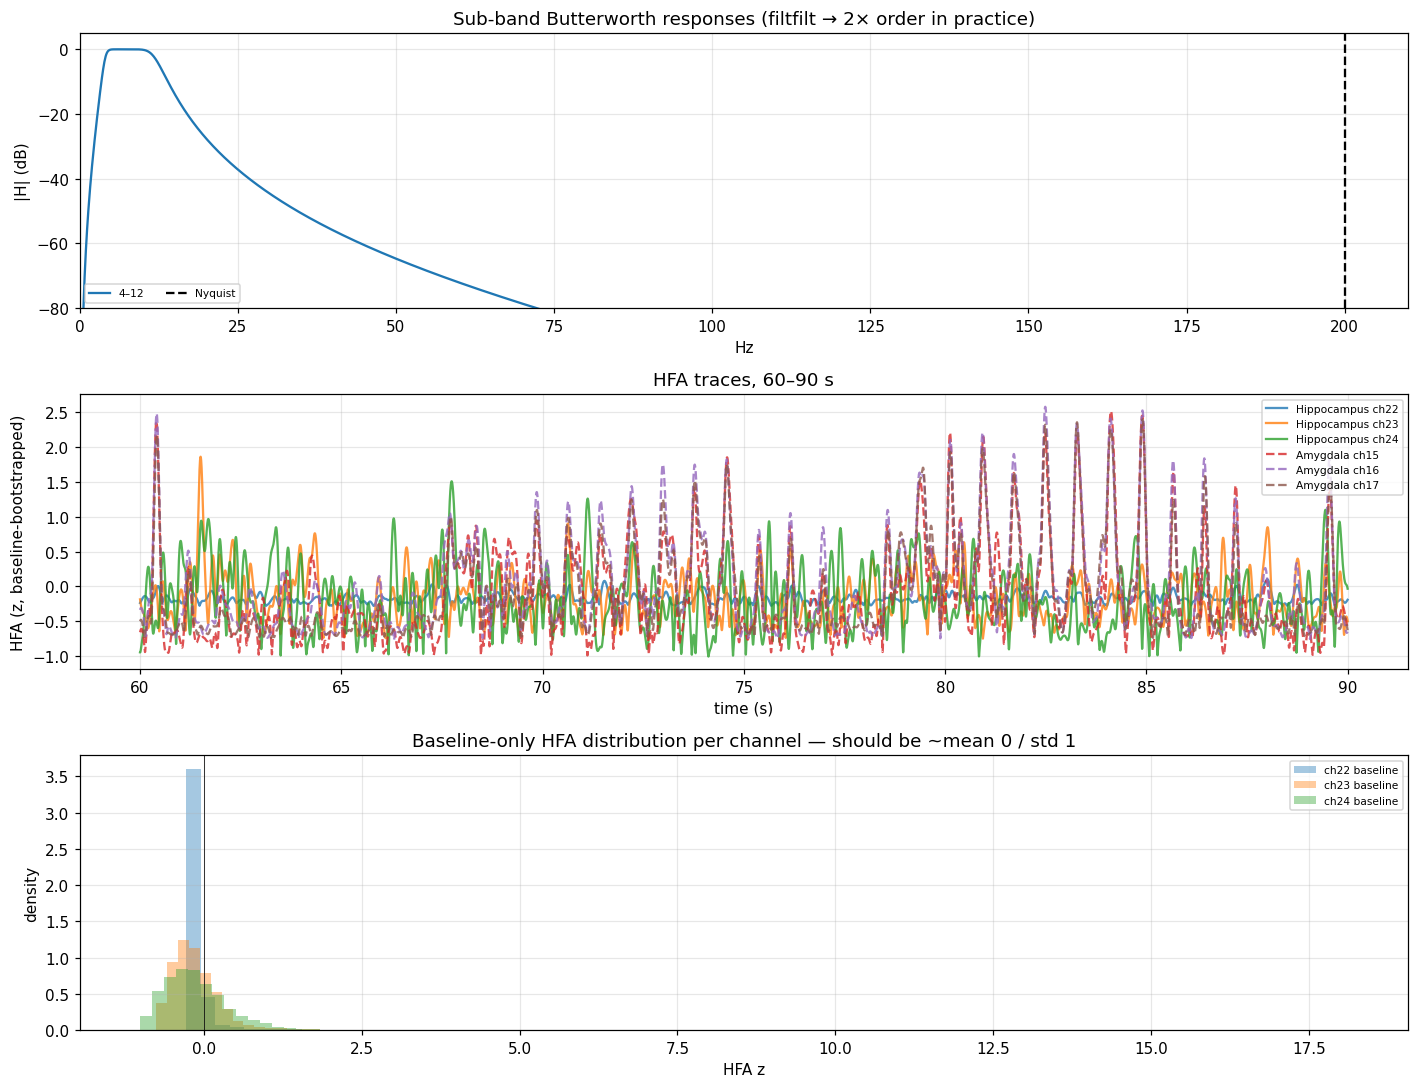


Baseline μ, σ per first-3-channel:
  ch22: μ=+0.000, σ=1.000
  ch23: μ=+0.000, σ=1.000
  ch24: μ=-0.000, σ=1.000


In [12]:
# QC: (a) sub-band filter response, (b) HFA traces for a few channels, (c) baseline distribution check.
fig, axes = plt.subplots(3, 1, figsize=(13, 10))

# (a) filter responses
from scipy.signal import freqz
for lo, hi in CONFIG['hfa_subband_edges']:
    b, a = design_subband_filter(pilot_fs, lo, hi, CONFIG['hfa_filter_order'])
    w, h = freqz(b, a, worN=2048, fs=pilot_fs)
    axes[0].plot(w, 20 * np.log10(np.abs(h) + 1e-12), label=f'{lo:.0f}–{hi:.0f}')
axes[0].axvline(pilot_fs / 2, linestyle='--', color='k', label='Nyquist')
axes[0].set_xlim(0, pilot_fs / 2 + 10); axes[0].set_ylim(-80, 5)
axes[0].set_xlabel('Hz'); axes[0].set_ylabel('|H| (dB)')
axes[0].set_title('Sub-band Butterworth responses (filtfilt → 2× order in practice)')
axes[0].legend(fontsize='x-small', ncol=2)

# (b) example HFA traces (first 3 src + first 3 tgt channels), 30 s of continuous trace
n_show = min(3, len(good_src))
n_show_t = min(3, len(good_tgt))
show_window_s = (60.0, 90.0)
s_idx = int(show_window_s[0] * pilot_fs)
e_idx = int(show_window_s[1] * pilot_fs)
for k in range(n_show):
    axes[1].plot(pilot_time[s_idx:e_idx], pilot_hfa[k, s_idx:e_idx],
                 label=f'{CONFIG["source_region"]} ch{good_src[k]}', alpha=0.8)
for k in range(n_show_t):
    src_n = len(good_src)
    axes[1].plot(pilot_time[s_idx:e_idx], pilot_hfa[src_n + k, s_idx:e_idx],
                 label=f'{CONFIG["target_region"]} ch{good_tgt[k]}', linestyle='--', alpha=0.8)
axes[1].set_xlabel('time (s)'); axes[1].set_ylabel('HFA (z, baseline-bootstrapped)')
axes[1].set_title(f'HFA traces, {show_window_s[0]:.0f}–{show_window_s[1]:.0f} s')
axes[1].legend(fontsize='x-small')

# (c) HFA value distribution at baseline indices vs full trace — should be ~N(0,1) at baseline
for k in range(min(3, pilot_hfa.shape[0])):
    base_vals = pilot_hfa[k, pilot_baseline_idx]
    axes[2].hist(base_vals, bins=80, alpha=0.4, density=True, label=f'ch{all_good_chans[k]} baseline')
axes[2].set_xlabel('HFA z'); axes[2].set_ylabel('density')
axes[2].set_title('Baseline-only HFA distribution per channel — should be ~mean 0 / std 1')
axes[2].axvline(0, color='k', lw=0.5)
axes[2].legend(fontsize='x-small')
plt.tight_layout(); plt.show()

print("\nBaseline μ, σ per first-3-channel:")
for k in range(min(3, pilot_hfa.shape[0])):
    base_vals = pilot_hfa[k, pilot_baseline_idx]
    print(f"  ch{all_good_chans[k]}: μ={base_vals.mean():+.3f}, σ={base_vals.std(ddof=1):.3f}")

## 5. Epoching → Trial Tensors

Cut continuous HFA into trials around the lock event. Output is a (n_trials, n_chan, n_timepoints) tensor *per region*, with parallel arrays of trial metadata. Per-trial peak-to-peak rejection is applied on the raw LFP (not HFA) to flag obvious artifact trials.

In [13]:
def epoch_continuous(continuous: np.ndarray, fs: float, lock_times: np.ndarray,
                     window):
    """Cut a (n_chan, T) array into a (n_trials, n_chan, n_t) tensor at lock_times ± window.

    Trials whose window falls outside the recording are dropped; returns the kept-trial mask too.
    """
    pre, post = window
    pre_n = int(round(pre * fs))
    post_n = int(round(post * fs))
    n_t = post_n - pre_n
    T = continuous.shape[-1]
    keep = np.ones(len(lock_times), dtype=bool)
    samples = []
    for ti, t in enumerate(lock_times):
        if not np.isfinite(t) or t <= 0:
            keep[ti] = False
            continue
        center = int(round(t * fs))
        s = center + pre_n
        e = center + post_n
        if s < 0 or e > T:
            keep[ti] = False
            continue
        samples.append(continuous[..., s:e])
    if not samples:
        return np.zeros((0,) + continuous.shape[:-1] + (n_t,), dtype=continuous.dtype), keep
    tensor = np.stack(samples, axis=0)
    rel_time = (np.arange(n_t) + pre_n) / fs
    return tensor, keep, rel_time


def per_trial_p2p_reject(lfp_trials: np.ndarray, threshold_uV: float):
    """Flag trials where any channel exceeds peak-to-peak threshold."""
    if threshold_uV is None or threshold_uV <= 0:
        return np.zeros(lfp_trials.shape[0], dtype=bool)
    p2p = lfp_trials.max(axis=-1) - lfp_trials.min(axis=-1)  # (n_trials, n_chan)
    return (p2p > threshold_uV).any(axis=1)


def group_trials_by_first_stim_category(trial_table, keep=(1, 2, 3, 4, 5)):
    """Group trials by the category of the first encoding stimulus.

    The category is encoded in the hundreds digit of `PicIDs_Encoding1`
    (e.g. 201 -> category 2, 503 -> category 5).

    Parameters
    ----------
    trial_table : pd.DataFrame
        Must contain `PicIDs_Encoding1`.
    keep : iterable of int
        Categories to include; trials whose category is not in this set
        are simply not assigned to any group (returned in `dropped_trials`).

    Returns dict shaped like `group_trials_by_load`, with extra `dropped_trials`.
    """
    if 'PicIDs_Encoding1' not in trial_table.columns:
        raise ValueError("trial_table must have a 'PicIDs_Encoding1' column")
    pic_ids = trial_table['PicIDs_Encoding1'].fillna(0).astype(int)
    cats = pic_ids // 100
    keep = list(keep)
    groups, group_labels, group_counts = [], [], []
    for c in keep:
        idx = np.where(cats.values == c)[0]
        groups.append(idx)
        group_labels.append(str(c))
        group_counts.append(len(idx))
    dropped_mask = ~cats.isin(keep) | (pic_ids == 0)
    dropped_trials = np.where(dropped_mask.values)[0]

    summary_lines = ['=== Trial Grouping by 1st-Stim Category ===',
                     f'Total trials: {len(trial_table)}',
                     f'Number of groups: {len(groups)}', '']
    for label, n in zip(group_labels, group_counts):
        summary_lines.append(f'  cat {label}: {n} trials')
    if len(dropped_trials):
        summary_lines.append(f'  [dropped] {len(dropped_trials)} trials not in keep={tuple(keep)}')
    return {
        'groups': groups,
        'load_values': keep,
        'group_labels': group_labels,
        'group_counts': group_counts,
        'summary': '\n'.join(summary_lines),
        'dropped_trials': dropped_trials,
    }


def get_trial_groups(trial_table, mode='category', keep=(1, 2, 3, 4, 5)):
    """Dispatch trial grouping based on CONFIG['trial_grouping']."""
    if mode == 'load':
        return group_trials_by_load(trial_table)
    if mode == 'category':
        return group_trials_by_first_stim_category(trial_table, keep=keep)
    raise ValueError(f"unknown trial_grouping mode: {mode!r}")


def build_trial_tensors(hfa: np.ndarray, lfp_clean: np.ndarray, fs: float,
                         src_chans, tgt_chans, hfa_chan_order,
                         trial_table: pd.DataFrame, cfg):
    """Return dict with {region: (n_trials, n_chan, n_t)}, kept-trial mask, and aligned metadata."""
    lock_col_map = {
        'encoding1': 'timestamps_Encoding1',
        'maintenance': 'timestamps_Maintenance',
        'probe': 'timestamps_Probe',
    }
    lock_col = lock_col_map[cfg['lock_event']]
    lock_times = trial_table[lock_col].to_numpy()
    window = cfg['epoch_window_active']

    src_idx_in_hfa = [hfa_chan_order.index(c) for c in src_chans]
    tgt_idx_in_hfa = [hfa_chan_order.index(c) for c in tgt_chans]

    src_hfa_continuous = hfa[src_idx_in_hfa]  # (n_src, T)
    tgt_hfa_continuous = hfa[tgt_idx_in_hfa]

    src_tensor, keep_src, rel_time = epoch_continuous(src_hfa_continuous, fs, lock_times, window)
    tgt_tensor, keep_tgt, _ = epoch_continuous(tgt_hfa_continuous, fs, lock_times, window)
    keep = keep_src & keep_tgt

    # raw-LFP P2P artifact rejection on src+tgt channels
    raw_for_p2p = lfp_clean.T[src_chans + tgt_chans]  # (n_chan, T) → (n_chan, T)
    raw_trials, _, _ = epoch_continuous(raw_for_p2p, fs, lock_times, window)
    p2p_bad = per_trial_p2p_reject(raw_trials, cfg['artifact_trial_p2p_uV'])
    # align p2p_bad with the keep mask (it has same length as lock_times because epoch_continuous
    # returns 0 trials when fully out of bounds — but we used the same lock_times)
    # the simplest robust path: re-run epoch_continuous so we have aligned indices
    # We already have keep above and raw_trials includes only kept trials in src+tgt sense —
    # rebuild indexing on the union of in-bounds indices to be safe:
    in_bounds = np.zeros(len(lock_times), dtype=bool)
    in_bounds[:len(p2p_bad)] = True  # only in-bounds trials produced p2p rows
    p2p_full = np.zeros(len(lock_times), dtype=bool)
    p2p_full[np.where(in_bounds)[0]] = p2p_bad
    keep = keep & ~p2p_full

    src_tensor = src_tensor[keep[:src_tensor.shape[0]] if src_tensor.shape[0] == keep.size else slice(None)]
    tgt_tensor = tgt_tensor[keep[:tgt_tensor.shape[0]] if tgt_tensor.shape[0] == keep.size else slice(None)]

    # If epoch_continuous already dropped out-of-bound trials, indexing above is a no-op.
    # The clean version is: rebuild epoch_continuous to apply keep itself. Doing that here:
    src_tensor_full, _, _ = epoch_continuous(src_hfa_continuous, fs, lock_times[keep], window)
    tgt_tensor_full, _, _ = epoch_continuous(tgt_hfa_continuous, fs, lock_times[keep], window)

    # Trial metadata aligned with kept trials
    meta = trial_table.loc[keep].copy()
    if cfg['use_only_correct'] and 'response_accuracy' in meta.columns:
        correct_mask = meta['response_accuracy'] == 1
        src_tensor_full = src_tensor_full[correct_mask.values]
        tgt_tensor_full = tgt_tensor_full[correct_mask.values]
        meta = meta[correct_mask].copy()

    return {
        CONFIG['source_region']: src_tensor_full,
        CONFIG['target_region']: tgt_tensor_full,
        'meta': meta.reset_index(drop=True),
        'rel_time': rel_time,
        'src_chans': src_chans,
        'tgt_chans': tgt_chans,
    }


print("epoching helpers defined")

epoching helpers defined


In [14]:
pilot_epoched = build_trial_tensors(
    hfa=pilot_hfa,
    lfp_clean=pilot_clean_lfp,
    fs=pilot_fs,
    src_chans=good_src,
    tgt_chans=good_tgt,
    hfa_chan_order=all_good_chans,
    trial_table=pilot_trials,
    cfg=CONFIG,
)
src_tensor = pilot_epoched[CONFIG['source_region']]
tgt_tensor = pilot_epoched[CONFIG['target_region']]
rel_time = pilot_epoched['rel_time']

print(f"src tensor: {src_tensor.shape}  (n_trials, n_chan, n_t)")
print(f"tgt tensor: {tgt_tensor.shape}")
print(f"rel_time: {rel_time[0]:.2f} → {rel_time[-1]:.2f} s, dt = {1/pilot_fs:.4f}s")

# Trial-condition split inspection
load_groups = get_trial_groups(pilot_epoched['meta'], mode=CONFIG['trial_grouping'], keep=CONFIG['category_keep'])
print("\n" + load_groups['summary'])

src tensor: (116, 14, 800)  (n_trials, n_chan, n_t)
tgt tensor: (116, 15, 800)
rel_time: 0.00 → 2.00 s, dt = 0.0025s

=== Trial Grouping by 1st-Stim Category ===
Total trials: 116
Number of groups: 5

  cat 1: 24 trials
  cat 2: 22 trials
  cat 3: 25 trials
  cat 4: 21 trials
  cat 5: 24 trials


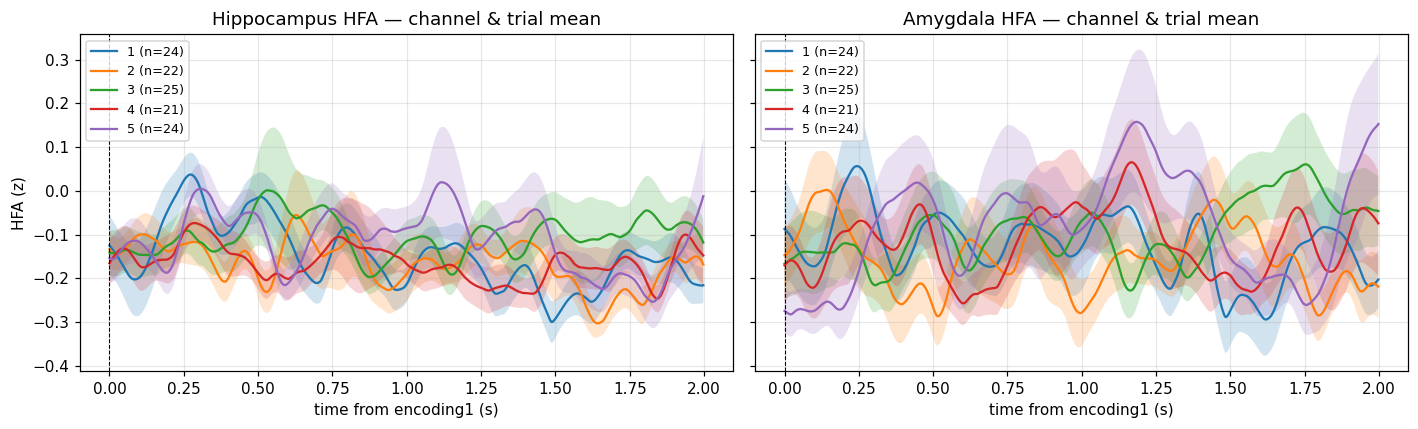

In [15]:
# QC plot: trial-mean HFA per region split by load
fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)
for ax, region, tensor in zip(
    axes,
    [CONFIG['source_region'], CONFIG['target_region']],
    [src_tensor, tgt_tensor],
):
    chan_mean = tensor.mean(axis=1)  # (n_trials, n_t) — collapse channels first
    for grp, label in zip(load_groups['groups'], load_groups['group_labels']):
        if len(grp) == 0:
            continue
        # group indices are positional in original meta; need to map to kept-meta
        grp_mask = np.isin(np.arange(chan_mean.shape[0]), grp)
        if grp_mask.sum() == 0:
            continue
        m = chan_mean[grp_mask].mean(axis=0)
        sem = scistats.sem(chan_mean[grp_mask], axis=0)
        ax.plot(rel_time, m, label=f'{label} (n={grp_mask.sum()})')
        ax.fill_between(rel_time, m - sem, m + sem, alpha=0.2)
    ax.axvline(0, color='k', lw=0.7, linestyle='--')
    ax.set_title(f'{region} HFA — channel & trial mean')
    ax.set_xlabel(f'time from {CONFIG["lock_event"]} (s)')
    ax.legend(fontsize='small')
axes[0].set_ylabel('HFA (z)')
plt.tight_layout(); plt.show()

src tensor (delay-locked): (130, 14, 1000)
tgt tensor (delay-locked): (130, 15, 1000)
rel_time: 0.00 → 2.50 s

=== Trial Grouping by 1st-Stim Category ===
Total trials: 130
Number of groups: 5

  cat 1: 28 trials
  cat 2: 28 trials
  cat 3: 26 trials
  cat 4: 25 trials
  cat 5: 23 trials


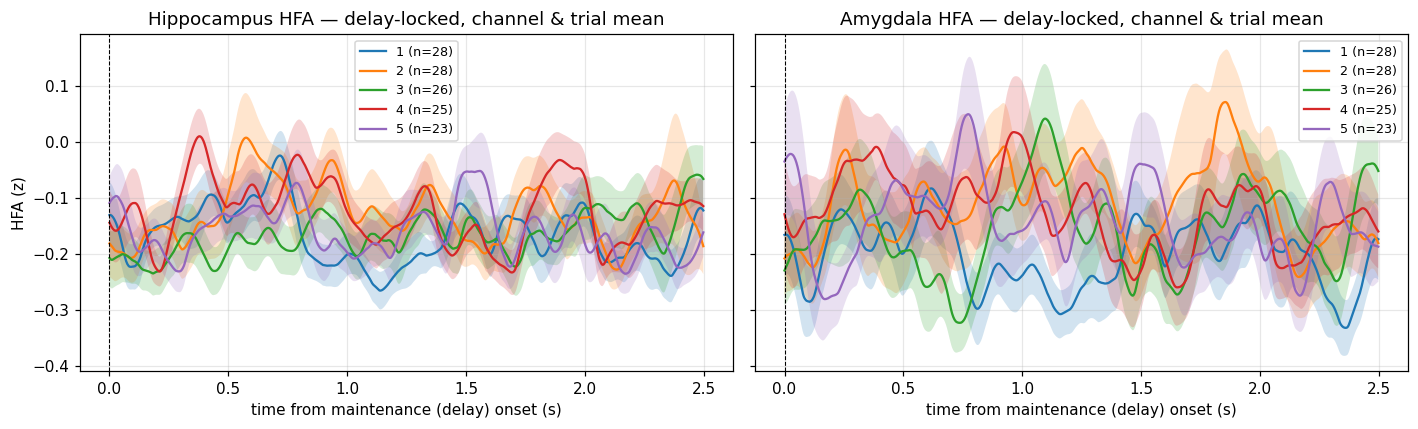

In [16]:
# Same QC plot but locked to delay (maintenance) onset, 2.5 s post-onset.
# Override CONFIG['lock_event'] / 'epoch_window_active' on a *copy* so the
# notebook state above stays untouched.
cfg_delay = dict(CONFIG)
cfg_delay['lock_event'] = 'maintenance'
cfg_delay['epoch_window_active'] = (0.0, 2.5)   # 0-2.5 s post-delay-onset (matches spec)

pilot_epoched_delay = build_trial_tensors(
    hfa=pilot_hfa,
    lfp_clean=pilot_clean_lfp,
    fs=pilot_fs,
    src_chans=good_src,
    tgt_chans=good_tgt,
    hfa_chan_order=all_good_chans,
    trial_table=pilot_trials,
    cfg=cfg_delay,
)
src_tensor_d = pilot_epoched_delay[CONFIG['source_region']]
tgt_tensor_d = pilot_epoched_delay[CONFIG['target_region']]
rel_time_d = pilot_epoched_delay['rel_time']
load_groups_d = get_trial_groups(pilot_epoched_delay['meta'], mode=CONFIG['trial_grouping'], keep=CONFIG['category_keep'])

print(f"src tensor (delay-locked): {src_tensor_d.shape}")
print(f"tgt tensor (delay-locked): {tgt_tensor_d.shape}")
print(f"rel_time: {rel_time_d[0]:.2f} → {rel_time_d[-1]:.2f} s")
print("\n" + load_groups_d['summary'])

fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)
for ax, region, tensor in zip(
    axes,
    [CONFIG['source_region'], CONFIG['target_region']],
    [src_tensor_d, tgt_tensor_d],
):
    chan_mean = tensor.mean(axis=1)  # (n_trials, n_t)
    for grp, label in zip(load_groups_d['groups'], load_groups_d['group_labels']):
        if len(grp) == 0:
            continue
        grp_mask = np.isin(np.arange(chan_mean.shape[0]), grp)
        if grp_mask.sum() == 0:
            continue
        m = chan_mean[grp_mask].mean(axis=0)
        sem = scistats.sem(chan_mean[grp_mask], axis=0)
        ax.plot(rel_time_d, m, label=f'{label} (n={grp_mask.sum()})')
        ax.fill_between(rel_time_d, m - sem, m + sem, alpha=0.2)
    ax.axvline(0, color='k', lw=0.7, linestyle='--')
    ax.set_title(f'{region} HFA — delay-locked, channel & trial mean')
    ax.set_xlabel('time from maintenance (delay) onset (s)')
    ax.legend(fontsize='small')
axes[0].set_ylabel('HFA (z)')
plt.tight_layout(); plt.show()

---
## CHECKPOINT — STOP HERE FOR FIRST PASS

Inspect the QC plots above before moving on. Things to verify:

1. **Filter response** — every sub-band has a clean passband, ≥40 dB stopband attenuation, and the highest sub-band isn't bumping into Nyquist roll-off too badly.
2. **Baseline z-distribution** — should be roughly mean 0, std 1 *at baseline indices* per channel. If σ is far from 1, the bootstrap is being dominated by trial-onset evoked activity bleeding into the baseline window — adjust `hfa_baseline_window`.
3. **Continuous HFA traces** — should look like noisy z-scored signals with occasional bursts. No DC drift, no obvious 60 Hz beat.
4. **Trial-mean HFA (load 1 vs load 3)** — both regions should show post-onset elevation; if load 1 and load 3 are perfectly overlapping that's a flag (could be normalization issue, could be no real load effect at this site).
5. **Per-region & per-channel artifact flags** — re-check `bad_chans` against any channels you know are epileptic from the dataset metadata.

Once those look sensible, the remaining sections (6–12) are scaffolded below with `# TODO` markers and decision-point notes. Each section is meant to be filled in incrementally.

## 6. Dimensionality Analysis (Binish Fig 2b analog)

For each session we fit factor analysis (FA) separately to source-region (hipp) and target-region (amyg) HFA. The dimensionality estimate per region per session is computed as follows, **per trial**, then averaged across trials:

1. Treat one trial's HFA as a `(n_t, n_chan)` data matrix (timepoints = samples, channels = features), optionally downsampled to break time-autocorrelation.
2. Run **K-fold cross-validated log-likelihood** across `m ∈ {1, …, n_chan-1}`. Pick `m_peak = argmax CV-LL`.
3. **Refit FA at m_peak** on the full trial.
4. SVD the loadings `L`. The eigenvalues of `LL^T` (= squared singular values of `L`) describe shared variance. Define **dimensionality = smallest m_eff such that cumulative shared variance ≥ 95 %**.
5. Also report **participation ratio** `(Σ λ_i)² / Σ λ_i²` from `LL^T` as a sanity check.

The FA fit uses our own EM implementation (no sklearn). For pilot QC we run on a **subset of trials** (`DIM_N_TRIALS`) to keep runtime reasonable; for the full all-sessions group analysis, set `DIM_N_TRIALS = None` and run the all-sessions cell at the bottom of this section.

**Decision points:**
- Downsampling factor — defaults to 4 (1200 → 300 samples per trial @ 400 Hz). Reduces autocorrelation bias in CV-LL.
- CV fold count — 5.
- m_grid — `range(1, n_chan)`.

**Group-level (across passing sessions):** paired Wilcoxon test on session-mean dim (hipp vs amyg) + boxplot.

In [17]:
# --- Temporal aggregation helper (block-avg or decimate) ---
def _aggregate(X, factor, method='block_avg'):
    """Reduce sample count along axis 0 by `factor`.

    method='decimate' : X[::factor] - keep every k-th sample.
    method='block_avg': non-overlapping mean over `factor`-sample windows.
                        Boxcar-filter-then-decimate; better SNR, less aliasing.
    """
    if factor is None or factor <= 1:
        return X
    if method == 'decimate':
        return X[::factor]
    if method == 'block_avg':
        n = (X.shape[0] // factor) * factor
        if n == 0:
            return X
        return X[:n].reshape(-1, factor, X.shape[1]).mean(axis=1)
    raise ValueError(f"unknown aggregation method: {method!r}")


# --- Factor Analysis EM (no sklearn) ---
# Model: x = L f + ε, with f ~ N(0, I_m), ε ~ N(0, Ψ),  Ψ diagonal.
# G = L L^T + Ψ; β = L^T G^-1.
# E-step: E[f|x] = β x;  E[f f^T | data] = I_m - β L + β S β^T  (S = sample cov).
# M-step: L_new = S β^T (E[f f^T])^-1;  Ψ_new = diag(S - L_new β S).

def factor_analysis_em(X, n_factors, max_iter=80, tol=1e-4, rng=None):
    """Fit FA via EM on (N, D) data. Returns dict with mean, L, psi, n_iter, ll_train."""
    rng = rng if rng is not None else np.random.default_rng(0)
    N, D = X.shape
    m = max(1, min(int(n_factors), D - 1))
    mean = X.mean(axis=0)
    Xc = X - mean
    S = (Xc.T @ Xc) / max(N, 1)
    L = rng.standard_normal((D, m)) * 0.1
    psi = np.maximum(np.diag(S).copy(), 1e-6)
    prev_ll, final_ll, n_iter = -np.inf, -np.inf, 0
    eyeD = np.eye(D); eyem = np.eye(m)
    for it in range(max_iter):
        G = L @ L.T + np.diag(psi) + 1e-8 * eyeD
        try:
            G_inv = np.linalg.inv(G)
        except np.linalg.LinAlgError:
            break
        beta = L.T @ G_inv                               # (m, D)
        E_ff = eyem - beta @ L + beta @ S @ beta.T       # (m, m)
        try:
            L_new = S @ beta.T @ np.linalg.inv(E_ff + 1e-8 * eyem)
        except np.linalg.LinAlgError:
            break
        psi_new = np.maximum(np.diag(S - L_new @ beta @ S), 1e-6)
        sign, logdet = np.linalg.slogdet(G)
        ll = -0.5 * (D * np.log(2 * np.pi) + logdet + np.trace(G_inv @ S))
        L, psi = L_new, psi_new
        n_iter = it + 1
        final_ll = ll
        if abs(ll - prev_ll) < tol:
            break
        prev_ll = ll
    return {'mean': mean, 'L': L, 'psi': psi, 'n_iter': n_iter, 'll_train': final_ll}


def fa_log_likelihood(X, fa):
    """Average per-sample log-likelihood of X under fa params."""
    Xc = X - fa['mean']
    D = Xc.shape[1]
    G = fa['L'] @ fa['L'].T + np.diag(fa['psi']) + 1e-8 * np.eye(D)
    sign, logdet = np.linalg.slogdet(G)
    G_inv = np.linalg.inv(G)
    quad = np.einsum('ni,ij,nj->n', Xc, G_inv, Xc).mean()
    return -0.5 * (D * np.log(2 * np.pi) + logdet + quad)


def cv_log_likelihood(X, m_grid, n_folds=5, max_iter=60, rng=None):
    """K-fold CV log-likelihood for each m. Returns (mean_ll, sem_ll, raw_lls)."""
    rng = rng if rng is not None else np.random.default_rng(0)
    N = X.shape[0]
    perm = rng.permutation(N)
    folds = np.array_split(perm, n_folds)
    lls = np.full((len(m_grid), n_folds), np.nan)
    for mi, m in enumerate(m_grid):
        for fi, test_idx in enumerate(folds):
            train_idx = np.setdiff1d(np.arange(N), test_idx)
            if len(train_idx) < int(m) + 5 or len(test_idx) < 2:
                continue
            fa = factor_analysis_em(X[train_idx], n_factors=m, max_iter=max_iter, rng=rng)
            lls[mi, fi] = fa_log_likelihood(X[test_idx], fa)
    n_valid = np.sum(~np.isnan(lls), axis=1)
    mean_ll = np.nanmean(lls, axis=1)
    sem_ll = np.nanstd(lls, axis=1) / np.sqrt(np.maximum(n_valid, 1))
    return mean_ll, sem_ll, lls


def dim_from_loadings(L, threshold=0.95):
    """Smallest m_eff with cumulative LL^T eigenvariance ≥ threshold."""
    s = np.linalg.svd(L, compute_uv=False)
    eigs = np.sort(s ** 2)[::-1]
    if eigs.sum() <= 0:
        return 0
    cumvar = np.cumsum(eigs) / eigs.sum()
    return int(np.argmax(cumvar >= threshold)) + 1


def participation_ratio(L):
    """PR = (Σ λ_i)^2 / Σ λ_i^2 from LL^T eigenvalues."""
    s = np.linalg.svd(L, compute_uv=False)
    eigs = s ** 2
    denom = (eigs ** 2).sum()
    return float((eigs.sum() ** 2) / denom) if denom > 0 else 0.0


print("FA + helpers defined")

FA + helpers defined


In [18]:
# Per-trial dimensionality estimator.
# tensor: (n_trials, n_chan, n_t).  Returns dict of per-trial scalars + diagnostics.
def estimate_dim_per_trial(tensor, m_grid=None, n_folds=5, downsample=4,
                            aggregate_method='block_avg',
                            max_iter=60, rng=None, verbose=False):
    rng = rng if rng is not None else np.random.default_rng(0)
    n_trials, n_chan, n_t = tensor.shape
    if m_grid is None:
        m_grid = np.arange(1, n_chan)  # 1 ... n_chan-1
    m_grid = np.asarray(m_grid, dtype=int)

    dims = np.full(n_trials, np.nan)
    m_peaks = np.full(n_trials, np.nan)
    prs = np.full(n_trials, np.nan)
    cv_ll_curves = np.full((n_trials, len(m_grid)), np.nan)

    for ti in range(n_trials):
        X = tensor[ti].T.astype(np.float64)  # (n_t, n_chan)
        X = _aggregate(X, downsample, method=aggregate_method)
        if X.shape[0] < (m_grid.max() + n_folds + 5):
            continue
        try:
            mean_ll, _, _ = cv_log_likelihood(X, m_grid, n_folds=n_folds, max_iter=max_iter, rng=rng)
            if not np.any(np.isfinite(mean_ll)):
                continue
            cv_ll_curves[ti] = mean_ll
            m_peak = int(m_grid[np.nanargmax(mean_ll)])
            fa_full = factor_analysis_em(X, n_factors=m_peak, max_iter=max_iter, rng=rng)
            dims[ti] = dim_from_loadings(fa_full['L'], threshold=0.95)
            m_peaks[ti] = m_peak
            prs[ti] = participation_ratio(fa_full['L'])
        except Exception as e:
            if verbose:
                print(f"  trial {ti}: {e}")
            continue
        if verbose and ((ti + 1) % 10 == 0 or ti == n_trials - 1):
            print(f"  trial {ti+1}/{n_trials}: m_peak={m_peaks[ti]:.0f}, dim95={dims[ti]:.0f}")

    return {'dim': dims, 'm_peak': m_peaks, 'pr': prs,
            'cv_ll': cv_ll_curves, 'm_grid': m_grid,
            'aggregate_method': aggregate_method, 'downsample': downsample}


print("per-trial dimensionality estimator defined")


per-trial dimensionality estimator defined


In [19]:
# --- Run on pilot session ---
# DECISION: subset trials for speed during interactive QC. Set DIM_N_TRIALS = None to use all.
DIM_N_TRIALS = None  # 'real' mode: use every kept trial in the session
DIM_DOWNSAMPLE = 8
DIM_AGGREGATE_METHOD = 'block_avg'   # 'block_avg' or 'decimate'
DIM_N_FOLDS = 5
DIM_MAX_ITER = 60

import time
rng_dim = np.random.default_rng(CONFIG['random_seed'] + 1)


def _subset(tensor, n):
    if n is None or n >= tensor.shape[0]:
        return tensor, np.arange(tensor.shape[0])
    idx = np.sort(rng_dim.choice(tensor.shape[0], size=n, replace=False))
    return tensor[idx], idx


src_sub, src_idx = _subset(src_tensor, DIM_N_TRIALS)
tgt_sub, tgt_idx = _subset(tgt_tensor, DIM_N_TRIALS)
print(f"Running per-trial FA on {src_sub.shape[0]} {CONFIG['source_region']} trials "
      f"and {tgt_sub.shape[0]} {CONFIG['target_region']} trials")
print(f"  aggregate: {DIM_AGGREGATE_METHOD} (factor={DIM_DOWNSAMPLE})  "
      f"-> samples/trial = {src_sub.shape[2] // DIM_DOWNSAMPLE}")
print(f"  m_grid src: 1..{src_sub.shape[1] - 1},  tgt: 1..{tgt_sub.shape[1] - 1}")
print(f"  cv folds = {DIM_N_FOLDS}, max EM iter = {DIM_MAX_ITER}")

t0 = time.time()
print(f"\n[{CONFIG['source_region']}]")
src_dim_res = estimate_dim_per_trial(
    src_sub, n_folds=DIM_N_FOLDS, downsample=DIM_DOWNSAMPLE,
    aggregate_method=DIM_AGGREGATE_METHOD,
    max_iter=DIM_MAX_ITER, rng=rng_dim, verbose=True,
)
t1 = time.time()
print(f"  -> {t1 - t0:.1f}s")

print(f"\n[{CONFIG['target_region']}]")
tgt_dim_res = estimate_dim_per_trial(
    tgt_sub, n_folds=DIM_N_FOLDS, downsample=DIM_DOWNSAMPLE,
    aggregate_method=DIM_AGGREGATE_METHOD,
    max_iter=DIM_MAX_ITER, rng=rng_dim, verbose=True,
)
t2 = time.time()
print(f"  -> {t2 - t1:.1f}s")


def _summary(name, res):
    d, mp, pr = res['dim'], res['m_peak'], res['pr']
    return (f"{name}: dim95 = {np.nanmean(d):.2f} +/- {np.nanstd(d):.2f} "
            f"(median {np.nanmedian(d):.1f}),  "
            f"m_peak = {np.nanmean(mp):.2f},  PR = {np.nanmean(pr):.2f}  "
            f"({np.sum(~np.isnan(d))}/{len(d)} trials valid)")

print("\n--- Per-trial pilot summary ---")
print(_summary(CONFIG['source_region'], src_dim_res))
print(_summary(CONFIG['target_region'], tgt_dim_res))


Running per-trial FA on 116 Hippocampus trials and 116 Amygdala trials
  aggregate: block_avg (factor=8)  -> samples/trial = 100
  m_grid src: 1..13,  tgt: 1..14
  cv folds = 5, max EM iter = 60

[Hippocampus]
  trial 10/116: m_peak=8, dim95=5
  trial 20/116: m_peak=9, dim95=4
  trial 30/116: m_peak=8, dim95=5
  trial 40/116: m_peak=10, dim95=5
  trial 50/116: m_peak=10, dim95=6
  trial 60/116: m_peak=11, dim95=4
  trial 70/116: m_peak=6, dim95=4
  trial 80/116: m_peak=8, dim95=5
  trial 90/116: m_peak=11, dim95=5
  trial 100/116: m_peak=12, dim95=4
  trial 110/116: m_peak=12, dim95=6
  trial 116/116: m_peak=9, dim95=4
  -> 35.1s

[Amygdala]
  trial 10/116: m_peak=12, dim95=6
  trial 20/116: m_peak=11, dim95=5
  trial 30/116: m_peak=9, dim95=3
  trial 40/116: m_peak=10, dim95=5
  trial 50/116: m_peak=13, dim95=4
  trial 60/116: m_peak=7, dim95=4
  trial 70/116: m_peak=14, dim95=6
  trial 80/116: m_peak=11, dim95=4
  trial 90/116: m_peak=8, dim95=5
  trial 100/116: m_peak=11, dim95=5
  

C:\Users\zhuj3\AppData\Local\Temp\ipykernel_42860\3187333522.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  parts = ax.boxplot(
C:\Users\zhuj3\AppData\Local\Temp\ipykernel_42860\3187333522.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  parts = ax.boxplot(
C:\Users\zhuj3\AppData\Local\Temp\ipykernel_42860\3187333522.py:32: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  parts = ax.boxplot(


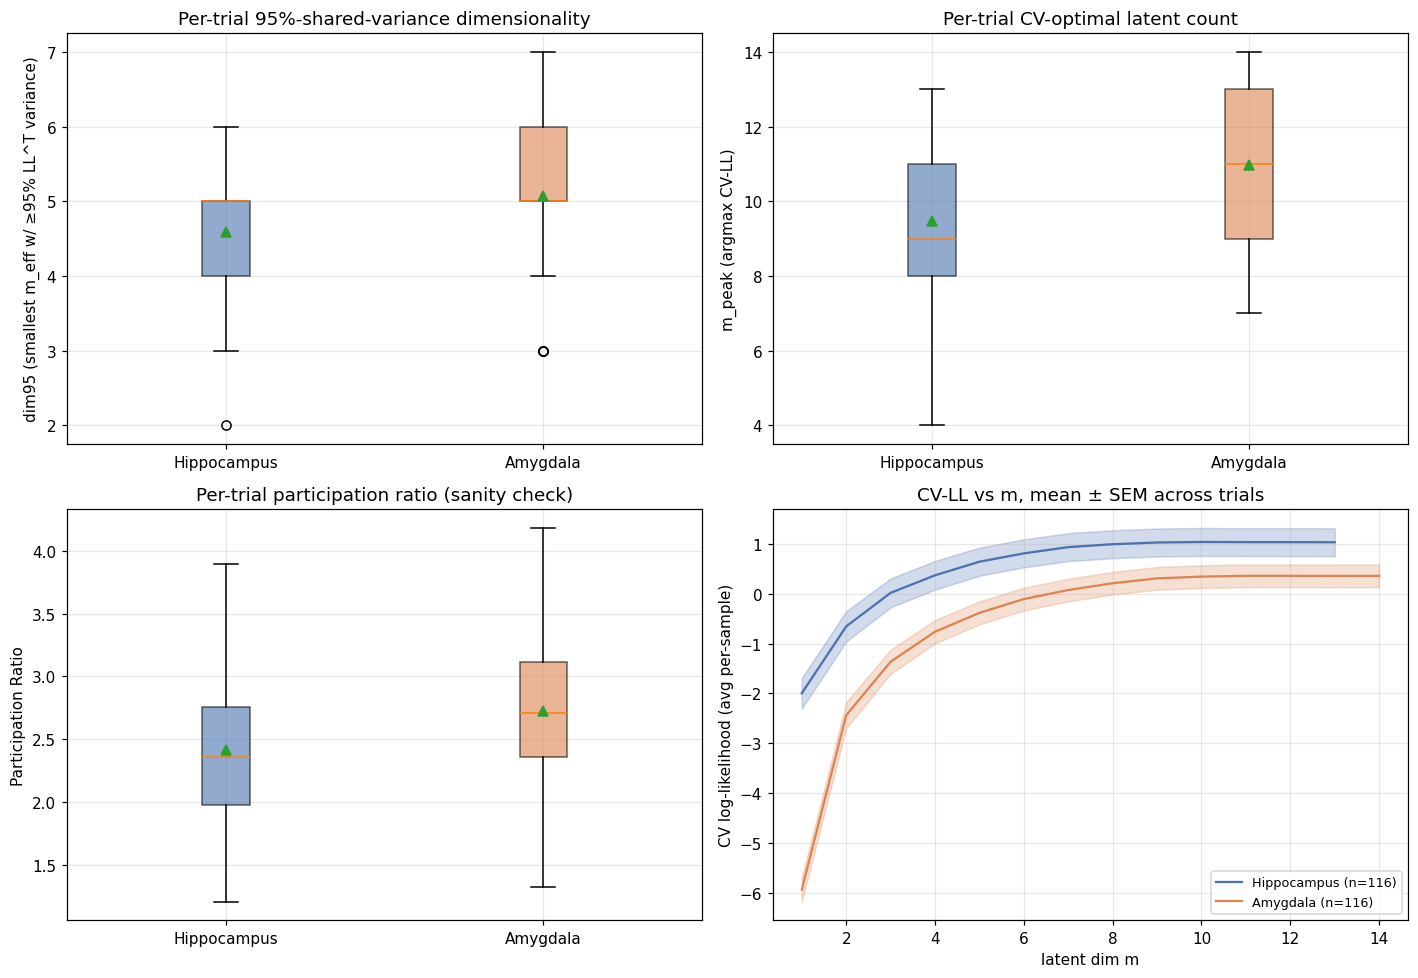

Within-pilot paired Wilcoxon (per-trial dim95):
  n_pairs = 116,  W = 674.5,  p = 5.795e-06
  median Hippocampus = 5.0,  median Amygdala = 5.0


In [20]:
# --- Plot per-trial dimensionality, m_peak, PR distributions + CV-LL curves ---
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# (a) dim95 distribution per region
ax = axes[0, 0]
parts = ax.boxplot(
    [src_dim_res['dim'][~np.isnan(src_dim_res['dim'])],
     tgt_dim_res['dim'][~np.isnan(tgt_dim_res['dim'])]],
    labels=[CONFIG['source_region'], CONFIG['target_region']],
    showmeans=True, patch_artist=True,
)
for patch, color in zip(parts['boxes'], ['#4C72B0', '#DD8452']):
    patch.set_facecolor(color); patch.set_alpha(0.6)
ax.set_ylabel('dim95 (smallest m_eff w/ ≥95% LL^T variance)')
ax.set_title('Per-trial 95%-shared-variance dimensionality')

# (b) m_peak distribution
ax = axes[0, 1]
parts = ax.boxplot(
    [src_dim_res['m_peak'][~np.isnan(src_dim_res['m_peak'])],
     tgt_dim_res['m_peak'][~np.isnan(tgt_dim_res['m_peak'])]],
    labels=[CONFIG['source_region'], CONFIG['target_region']],
    showmeans=True, patch_artist=True,
)
for patch, color in zip(parts['boxes'], ['#4C72B0', '#DD8452']):
    patch.set_facecolor(color); patch.set_alpha(0.6)
ax.set_ylabel('m_peak (argmax CV-LL)')
ax.set_title('Per-trial CV-optimal latent count')

# (c) Participation ratio distribution
ax = axes[1, 0]
parts = ax.boxplot(
    [src_dim_res['pr'][~np.isnan(src_dim_res['pr'])],
     tgt_dim_res['pr'][~np.isnan(tgt_dim_res['pr'])]],
    labels=[CONFIG['source_region'], CONFIG['target_region']],
    showmeans=True, patch_artist=True,
)
for patch, color in zip(parts['boxes'], ['#4C72B0', '#DD8452']):
    patch.set_facecolor(color); patch.set_alpha(0.6)
ax.set_ylabel('Participation Ratio')
ax.set_title('Per-trial participation ratio (sanity check)')

# (d) CV log-likelihood curves (mean ± SEM across trials)
ax = axes[1, 1]
for label, color, res in [
    (CONFIG['source_region'], '#4C72B0', src_dim_res),
    (CONFIG['target_region'], '#DD8452', tgt_dim_res),
]:
    curves = res['cv_ll']  # (n_trials, len(m_grid))
    valid = ~np.isnan(curves).all(axis=1)
    if not valid.any():
        continue
    m = np.nanmean(curves[valid], axis=0)
    n_v = np.sum(~np.isnan(curves[valid]), axis=0)
    sem = np.nanstd(curves[valid], axis=0) / np.sqrt(np.maximum(n_v, 1))
    ax.plot(res['m_grid'], m, color=color, label=f'{label} (n={valid.sum()})')
    ax.fill_between(res['m_grid'], m - sem, m + sem, color=color, alpha=0.25)
ax.set_xlabel('latent dim m')
ax.set_ylabel('CV log-likelihood (avg per-sample)')
ax.set_title('CV-LL vs m, mean ± SEM across trials')
ax.legend(fontsize='small')

plt.tight_layout(); plt.show()

# Within-session paired test: src vs tgt dim (one trial = one paired observation)
# Note: trial subsets for src and tgt may differ (we sampled independently); align here.
common = np.intersect1d(src_idx, tgt_idx)
src_pos = np.array([np.where(src_idx == c)[0][0] for c in common])
tgt_pos = np.array([np.where(tgt_idx == c)[0][0] for c in common])
src_vals = src_dim_res['dim'][src_pos]
tgt_vals = tgt_dim_res['dim'][tgt_pos]
mask = ~(np.isnan(src_vals) | np.isnan(tgt_vals))
if mask.sum() >= 8:
    stat, p = scistats.wilcoxon(src_vals[mask], tgt_vals[mask], zero_method='wilcox')
    print(f"Within-pilot paired Wilcoxon (per-trial dim95):"
          f"\n  n_pairs = {mask.sum()},  W = {stat:.1f},  p = {p:.4g}")
    print(f"  median {CONFIG['source_region']} = {np.median(src_vals[mask]):.1f},  "
          f"median {CONFIG['target_region']} = {np.median(tgt_vals[mask]):.1f}")
else:
    print(f"[skip] not enough paired trials for Wilcoxon (n={mask.sum()})")

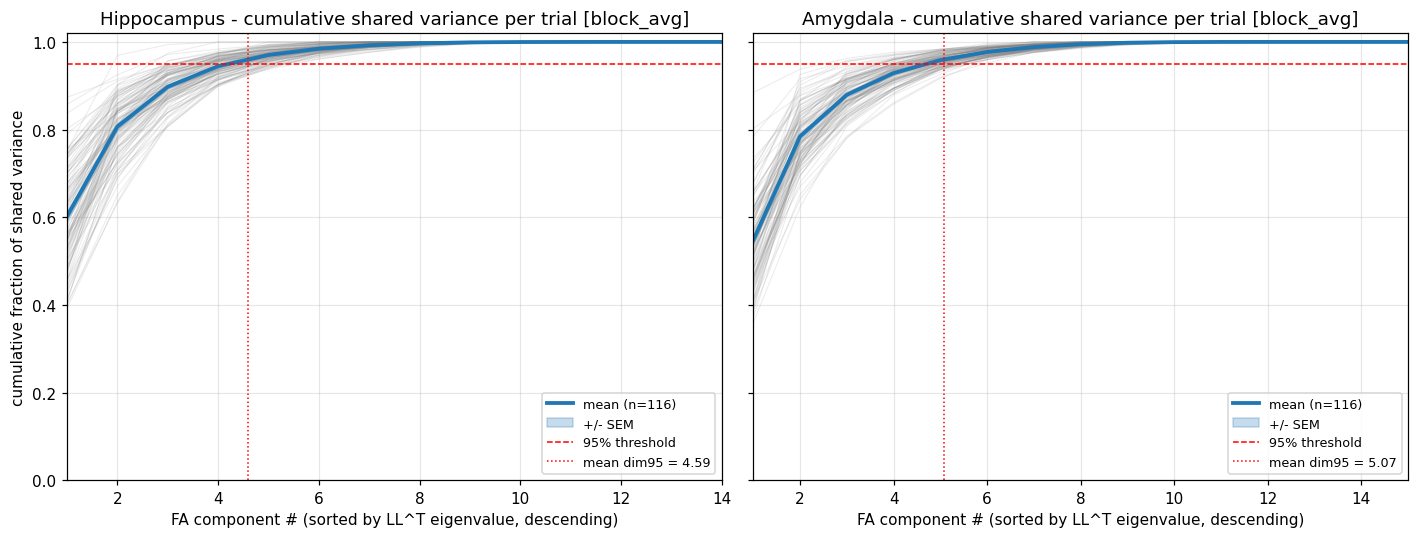

In [21]:
# --- Cumulative shared-variance curve (component # on x, cum-var on y).
# For each trial: refit FA at its m_peak, take eigenvalues of LL^T (= squared
# singular values of L), normalize by total -> cumulative fraction.
# Plot one curve per trial (faint) plus mean +/- SEM, per region. The dim95
# estimate is the x where each curve crosses the dashed 0.95 line.

def cumvar_curves_from_trials(tensor, m_peaks, max_iter=DIM_MAX_ITER,
                              downsample=DIM_DOWNSAMPLE,
                              aggregate_method=DIM_AGGREGATE_METHOD, rng=None):
    """Return (n_trials, n_chan) array of cumulative shared-variance fractions.

    Each row is the cumulative cascade up to the trial's m_peak; padded to
    n_chan by holding the final value flat so curves of different lengths
    can be averaged.
    """
    rng = rng if rng is not None else np.random.default_rng(0)
    n_trials, n_chan, _ = tensor.shape
    curves = np.full((n_trials, n_chan), np.nan)
    for ti in range(n_trials):
        if np.isnan(m_peaks[ti]):
            continue
        m_p = int(m_peaks[ti])
        X = tensor[ti].T.astype(np.float64)
        X = _aggregate(X, downsample, method=aggregate_method)
        try:
            fa = factor_analysis_em(X, n_factors=m_p, max_iter=max_iter, rng=rng)
            s = np.linalg.svd(fa['L'], compute_uv=False)
            eigs = np.sort(s ** 2)[::-1]
            if eigs.sum() <= 0:
                continue
            cum = np.cumsum(eigs) / eigs.sum()
            padded = np.ones(n_chan)
            padded[:len(cum)] = cum
            if len(cum) < n_chan:
                padded[len(cum):] = cum[-1]
            curves[ti] = padded
        except Exception:
            continue
    return curves


rng_cv = np.random.default_rng(CONFIG['random_seed'] + 2)
src_cumvar = cumvar_curves_from_trials(src_sub, src_dim_res['m_peak'], rng=rng_cv)
tgt_cumvar = cumvar_curves_from_trials(tgt_sub, tgt_dim_res['m_peak'], rng=rng_cv)

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
for ax, region, curves, dims in zip(
    axes,
    [CONFIG['source_region'], CONFIG['target_region']],
    [src_cumvar, tgt_cumvar],
    [src_dim_res['dim'], tgt_dim_res['dim']],
):
    n_chan = curves.shape[1]
    comp_idx = np.arange(1, n_chan + 1)
    valid_rows = ~np.isnan(curves).all(axis=1)
    if not valid_rows.any():
        ax.set_title(f'{region} - no valid trials')
        continue
    for r in curves[valid_rows]:
        ax.plot(comp_idx, r, color='gray', alpha=0.15, lw=0.7)
    mean = np.nanmean(curves[valid_rows], axis=0)
    sem = np.nanstd(curves[valid_rows], axis=0) / np.sqrt(valid_rows.sum())
    ax.plot(comp_idx, mean, color='C0', lw=2.5, label=f'mean (n={valid_rows.sum()})')
    ax.fill_between(comp_idx, mean - sem, mean + sem, color='C0', alpha=0.25, label='+/- SEM')
    ax.axhline(0.95, color='red', linestyle='--', lw=1.0, label='95% threshold')
    mean_dim = np.nanmean(dims)
    if np.isfinite(mean_dim):
        ax.axvline(mean_dim, color='red', linestyle=':', lw=1.0,
                   label=f'mean dim95 = {mean_dim:.2f}')
    ax.set_xlabel('FA component # (sorted by LL^T eigenvalue, descending)')
    ax.set_xlim(1, n_chan)
    ax.set_ylim(0, 1.02)
    ax.set_title(f'{region} - cumulative shared variance per trial '
                 f'[{DIM_AGGREGATE_METHOD}]')
    ax.legend(loc='lower right', fontsize='small')
axes[0].set_ylabel('cumulative fraction of shared variance')
plt.tight_layout(); plt.show()


In [135]:
# --- All-sessions group-level dimensionality (Binish Fig 2b analog).
# This is slow: ~1-3 min per session depending on channel count and DIM_N_TRIALS.
# Toggle RUN_ALL_SESSIONS_DIM = True to actually execute it.

RUN_ALL_SESSIONS_DIM = False
ALL_DIM_N_TRIALS = 30  # per session; set to None to use all trials

if RUN_ALL_SESSIONS_DIM:
    group_rows = []
    for sess_i, sess in passing.reset_index(drop=True).iterrows():
        print(f"\n=== [{sess_i+1}/{len(passing)}] {sess['subject']}/{sess['session']} ===")
        try:
            d = load_nwb_file(sess['filepath'])
            clean_lfp, fs_s, edf_s, _ = preprocess_session_lfp(d, CONFIG, verbose=False)
            region_chans_s, _ = extract_region_channels(edf_s)
            src_chans_s = region_chans_s[CONFIG['source_region']]
            tgt_chans_s = region_chans_s[CONFIG['target_region']]
            cand = src_chans_s + tgt_chans_s
            bad_s, _ = detect_artifact_channels(
                clean_lfp, cand, amp_z=CONFIG['artifact_amp_z'], var_z=CONFIG['artifact_var_z'])
            gs = [c for c in src_chans_s if c not in bad_s]
            gt = [c for c in tgt_chans_s if c not in bad_s]
            if len(gs) < 4 or len(gt) < 4:
                print(f"  [skip] insufficient good channels (src={len(gs)}, tgt={len(gt)})")
                continue
            all_chans = gs + gt
            rng_s = np.random.default_rng(CONFIG['random_seed'] + sess_i)
            hfa_s, _ = extract_hfa_session(clean_lfp, fs_s, all_chans, d['trials'], CONFIG, rng=rng_s)
            ep_s = build_trial_tensors(
                hfa=hfa_s, lfp_clean=clean_lfp, fs=fs_s,
                src_chans=gs, tgt_chans=gt, hfa_chan_order=all_chans,
                trial_table=d['trials'], cfg=CONFIG,
            )
            src_t = ep_s[CONFIG['source_region']]
            tgt_t = ep_s[CONFIG['target_region']]
            src_t_sub, _ = _subset(src_t, ALL_DIM_N_TRIALS)
            tgt_t_sub, _ = _subset(tgt_t, ALL_DIM_N_TRIALS)
            r_src = estimate_dim_per_trial(src_t_sub, n_folds=DIM_N_FOLDS,
                                            downsample=DIM_DOWNSAMPLE, aggregate_method=DIM_AGGREGATE_METHOD,
                                            max_iter=DIM_MAX_ITER, rng=rng_s)
            r_tgt = estimate_dim_per_trial(tgt_t_sub, n_folds=DIM_N_FOLDS,
                                            downsample=DIM_DOWNSAMPLE, aggregate_method=DIM_AGGREGATE_METHOD,
                                            max_iter=DIM_MAX_ITER, rng=rng_s)
            row = {
                'subject': sess['subject'],
                'session': sess['session'],
                f'dim_{CONFIG["source_region"]}': float(np.nanmean(r_src['dim'])),
                f'dim_{CONFIG["target_region"]}': float(np.nanmean(r_tgt['dim'])),
                f'm_peak_{CONFIG["source_region"]}': float(np.nanmean(r_src['m_peak'])),
                f'm_peak_{CONFIG["target_region"]}': float(np.nanmean(r_tgt['m_peak'])),
                f'pr_{CONFIG["source_region"]}': float(np.nanmean(r_src['pr'])),
                f'pr_{CONFIG["target_region"]}': float(np.nanmean(r_tgt['pr'])),
                'n_chans_src': len(gs), 'n_chans_tgt': len(gt),
            }
            group_rows.append(row)
            _sd = row[f"dim_{CONFIG['source_region']}"]
            _td = row[f"dim_{CONFIG['target_region']}"]
            print(f"  src dim95 = {_sd:.2f},  tgt dim95 = {_td:.2f}")
            d['io'].close()
        except Exception as e:
            print(f"  [error] {e}")
            continue

    group_dim = pd.DataFrame(group_rows)
    group_dim.to_csv(OUT_DIR / 'group_dimensionality.csv', index=False)
    print(f"\nSaved {len(group_dim)} sessions → {OUT_DIR / 'group_dimensionality.csv'}")
    print(group_dim.describe().T[['mean', 'std', 'min', '50%', 'max']])

    # Group-level Wilcoxon paired test on session-mean dim95
    src_dim_col = f'dim_{CONFIG["source_region"]}'
    tgt_dim_col = f'dim_{CONFIG["target_region"]}'
    paired = group_dim.dropna(subset=[src_dim_col, tgt_dim_col])
    if len(paired) >= 5:
        stat, p = scistats.wilcoxon(paired[src_dim_col], paired[tgt_dim_col], zero_method='wilcox')
        print(f"\nGroup paired Wilcoxon (session-mean dim95): "
              f"n={len(paired)}, W={stat:.1f}, p={p:.4g}")

    # Boxplot
    fig, ax = plt.subplots(figsize=(6, 5))
    parts = ax.boxplot(
        [paired[src_dim_col], paired[tgt_dim_col]],
        labels=[CONFIG['source_region'], CONFIG['target_region']],
        showmeans=True, patch_artist=True,
    )
    for patch, color in zip(parts['boxes'], ['#4C72B0', '#DD8452']):
        patch.set_facecolor(color); patch.set_alpha(0.6)
    # paired dots + lines
    x = [1, 2]
    for _, r in paired.iterrows():
        ax.plot(x, [r[src_dim_col], r[tgt_dim_col]], 'k-', alpha=0.25, lw=0.7)
        ax.plot(x, [r[src_dim_col], r[tgt_dim_col]], 'ko', alpha=0.4, markersize=4)
    ax.set_ylabel('Session-mean dim95')
    ax.set_title(f'Group-level dimensionality (n={len(paired)} sessions)')
    plt.tight_layout(); plt.show()
else:
    print("RUN_ALL_SESSIONS_DIM = False — skipping group-level loop.")
    print("Set RUN_ALL_SESSIONS_DIM = True (and optionally ALL_DIM_N_TRIALS = None) to run it.")

RUN_ALL_SESSIONS_DIM = False — skipping group-level loop.
Set RUN_ALL_SESSIONS_DIM = True (and optionally ALL_DIM_N_TRIALS = None) to run it.


## 7. Reduced-Rank Regression — the technical core

For each session we run **three** RRR configurations:
1. **Communication subspace (CS)** — source = hipp, target = amyg.
2. **Within-source control** (PFC-PFC analog) — split hipp channels into two non-overlapping halves; predict one from the other.
3. **Reverse direction** — source = amyg, target = hipp. (Binish didn't run this since PFC→M1 is anatomically unidirectional, but hipp↔amyg is reciprocal so we check.)

**Pipeline per iteration:**
1. Build the data matrix per region: condition-average HFA across trials within each `CONFIG['trial_grouping']` bin (currently `category`), block-aggregate in time (factor `DIM_DOWNSAMPLE`, method `DIM_AGGREGATE_METHOD`), stack into `(n_cond × n_t_after_agg, n_chan)`.
2. Subsample N channels (default 10) from each pool — *with replacement* for cross-region, *non-overlapping* for within-source.
3. K-fold CV: for each `(α, rank m)`, fit B_OLS = (X'X + αI)⁻¹ X'Y on train; SVD `Y_hat = X B_OLS = U Σ V'`; rank-m projection `B_RRR = B_OLS V_m V_m'`; evaluate R² on held-out test fold.
4. Pick best α as the one whose peak-over-ranks mean CV R² is largest. Within that α, pick **smallest m within 1 SE of peak R²** = the iteration's CS dim estimate.

**Decision points / defaults:**
- `RRR_N_CHANS = 10` channels per side (matches Binish).
- `RRR_N_ITERS = 100` for the pilot demo, bump to 1000 for the final group analysis (config knob below).
- `RRR_N_FOLDS = 10`.
- `RRR_ALPHA_GRID = CONFIG['rrr_alpha_grid']` (default `np.logspace(-3, 3, 13)`).
- Condition split = whatever `CONFIG['trial_grouping']` is (currently 1st-stim category, 5 categories).
- Block-avg downsampling factor = `DIM_DOWNSAMPLE` (shared with section 6).

Cross-check the math against Binish/Semedo's reference port at https://github.com/nehabinish/pfc-m1-communication-subspace before treating any number as final.

**Three RRR runs in two epochs (one session pipeline):**
1. **Encoding-cat** (window 0–2 s post-encoding1, all trials, group by 1st-stim category) — `res_cs`, `res_within`, `res_reverse`.
2. **Delay-cat-load1** (window 0–2.5 s post-maintenance, **load == 1 trials only**, group by 1st-stim category) — `res_cs_d`, `res_within_d`, `res_reverse_d`. Restricted to load-1 because in load-3 trials the delay holds 3 mixed-category stims, making "1st-stim category" a noisy label for that activity.
3. **Delay-load** (window 0–2.5 s post-maintenance, all trials, group by **load** — 2 groups: load 1, load 3) — `res_cs_d_load`, `res_within_d_load`, `res_reverse_d_load`. Tests load-driven WM coupling regardless of stim category.

Each run produces three configurations (CS / Within-source / Reverse) × `RRR_N_ITERS` bootstrap iterations.


In [136]:
# --- RRR helpers (numpy-only, no sklearn) ---
# Model: Y = X B + ε with reduced rank constraint rank(B) ≤ m.
# Two-step solve: ridge-regularized OLS, then SVD-based rank truncation.

def build_rrr_data_matrix(tensor, groups, downsample, aggregate_method):
    """Condition-average HFA across trials, aggregate in time, flatten.

    tensor : (n_trials, n_chan, n_t)
    groups : list of trial-index arrays per condition
    Returns : (n_cond * n_t_after_agg, n_chan)
    """
    pieces = []
    for grp in groups:
        if len(grp) == 0:
            continue
        cond_avg = tensor[grp].mean(axis=0).T.astype(np.float64)  # (n_t, n_chan)
        cond_avg = _aggregate(cond_avg, downsample, method=aggregate_method)
        pieces.append(cond_avg)
    if not pieces:
        return np.zeros((0, tensor.shape[1]), dtype=np.float64)
    return np.concatenate(pieces, axis=0)


def fit_rrr_full(X, Y, alpha):
    """Fit ridge-OLS, return (B_OLS, V) where V holds right singular vectors of Y_hat."""
    n_x = X.shape[1]
    XtX = X.T @ X
    XtY = X.T @ Y
    B_OLS = np.linalg.solve(XtX + alpha * np.eye(n_x), XtY)
    Y_hat = X @ B_OLS
    _, _, Vt = np.linalg.svd(Y_hat, full_matrices=False)
    return B_OLS, Vt.T


def rrr_r2(X_test, Y_test, B):
    Y_pred = X_test @ B
    ss_res = ((Y_test - Y_pred) ** 2).sum()
    ss_tot = ((Y_test - Y_test.mean(axis=0)) ** 2).sum() + 1e-12
    return 1.0 - ss_res / ss_tot


def cv_rrr_r2(X, Y, alpha_grid, rank_grid, n_folds=10, rng=None):
    """K-fold CV R² over (alpha, rank). Returns (n_alpha, n_rank, n_folds) array."""
    rng = rng if rng is not None else np.random.default_rng(0)
    N = X.shape[0]
    perm = rng.permutation(N)
    folds = np.array_split(perm, n_folds)
    rank_grid = np.asarray(rank_grid, dtype=int)
    r2 = np.full((len(alpha_grid), len(rank_grid), n_folds), np.nan)
    for fi, test_idx in enumerate(folds):
        train_idx = np.setdiff1d(np.arange(N), test_idx)
        Xtr, Ytr = X[train_idx], Y[train_idx]
        Xte, Yte = X[test_idx], Y[test_idx]
        for ai, alpha in enumerate(alpha_grid):
            try:
                B_OLS, V = fit_rrr_full(Xtr, Ytr, alpha)
            except np.linalg.LinAlgError:
                continue
            n_v = V.shape[1]
            for ri, m in enumerate(rank_grid):
                m_clip = min(int(m), n_v)
                Vm = V[:, :m_clip]
                B_m = B_OLS @ Vm @ Vm.T
                r2[ai, ri, fi] = rrr_r2(Xte, Yte, B_m)
    return r2


def select_alpha_and_dim_1se(r2_grid, alpha_grid, rank_grid):
    """Returns (best_alpha, cs_dim, mean_r2_at_best_alpha, sem_r2_at_best_alpha).

    Best alpha = argmax over alphas of (max over ranks of mean R² across folds).
    cs_dim = smallest rank within 1 SE of the peak R² at the chosen alpha.
    """
    rank_grid = np.asarray(rank_grid, dtype=int)
    mean_r2 = np.nanmean(r2_grid, axis=2)            # (n_alpha, n_rank)
    sem_r2 = np.nanstd(r2_grid, axis=2) / np.sqrt(np.maximum(r2_grid.shape[2], 1))
    if not np.any(np.isfinite(mean_r2)):
        return np.nan, np.nan, mean_r2[0] if mean_r2.size else np.array([]), sem_r2[0] if sem_r2.size else np.array([])
    peak_per_alpha = np.nanmax(mean_r2, axis=1)
    ai_best = int(np.nanargmax(peak_per_alpha))
    best_alpha = alpha_grid[ai_best]
    r2_at_best = mean_r2[ai_best]
    sem_at_best = sem_r2[ai_best]
    peak_idx = int(np.nanargmax(r2_at_best))
    threshold = r2_at_best[peak_idx] - sem_at_best[peak_idx]
    valid = (r2_at_best >= threshold) & np.isfinite(r2_at_best)
    if not valid.any():
        return best_alpha, np.nan, r2_at_best, sem_at_best
    cs_dim = int(rank_grid[np.where(valid)[0][0]])
    return best_alpha, cs_dim, r2_at_best, sem_at_best


def bootstrap_rrr(X_pool, Y_pool, n_chans_x, n_chans_y, n_iters,
                  alpha_grid, rank_grid, n_folds, rng,
                  sampling='replace', verbose=True):
    """Bootstrap over channel subsamples.

    sampling='replace'  : independent with-replacement subsamples from each pool
    sampling='disjoint' : non-overlapping subsamples drawn from the *same* pool
                          (X_pool must `is` Y_pool in this case)
    """
    n_x_total = X_pool.shape[1]
    n_y_total = Y_pool.shape[1]
    rank_grid = np.asarray(rank_grid, dtype=int)
    res = {
        'cs_dim': np.full(n_iters, np.nan),
        'best_alpha': np.full(n_iters, np.nan),
        'best_r2': np.full(n_iters, np.nan),
        'r2_curves': np.full((n_iters, len(rank_grid)), np.nan),
        'sem_curves': np.full((n_iters, len(rank_grid)), np.nan),
        'rank_grid': rank_grid,
    }
    for it in range(n_iters):
        if sampling == 'disjoint':
            n_total = n_x_total
            req = n_chans_x + n_chans_y
            nx = ny = (n_total // 2) if req > n_total else n_chans_x
            perm = rng.permutation(n_total)
            x_idx = perm[:nx]
            y_idx = perm[nx:nx + ny]
        else:
            x_idx = rng.choice(n_x_total, n_chans_x, replace=True)
            y_idx = rng.choice(n_y_total, n_chans_y, replace=True)
        Xb = X_pool[:, x_idx]
        Yb = Y_pool[:, y_idx]
        try:
            r2 = cv_rrr_r2(Xb, Yb, alpha_grid, rank_grid, n_folds=n_folds, rng=rng)
            best_alpha, cs_dim, mean_r2, sem_r2 = select_alpha_and_dim_1se(r2, alpha_grid, rank_grid)
            res['cs_dim'][it] = cs_dim
            res['best_alpha'][it] = best_alpha
            res['r2_curves'][it] = mean_r2
            res['sem_curves'][it] = sem_r2
            res['best_r2'][it] = np.nanmax(mean_r2) if np.any(np.isfinite(mean_r2)) else np.nan
        except Exception:
            continue
        if verbose and ((it + 1) % 25 == 0 or it == n_iters - 1):
            d = res['cs_dim'][it]
            r2v = res['best_r2'][it]
            print(f"  iter {it+1}/{n_iters}: cs_dim={d}, peak R²={r2v:.3f}")
    return res


print("RRR helpers defined")


RRR helpers defined


In [137]:
# --- Run RRR on pilot session: 3 configurations ---
RRR_N_ITERS = 1000                # 'real' mode: full Binish-spec bootstrap count
RRR_N_CHANS = 10                  # channels per side (with replacement for cross-region)
RRR_N_FOLDS = 10
RRR_ALPHA_GRID = CONFIG['rrr_alpha_grid']
RRR_DOWNSAMPLE = DIM_DOWNSAMPLE
RRR_AGGREGATE = DIM_AGGREGATE_METHOD

# Use whatever trial grouping is currently active (category by default)
trial_groups = get_trial_groups(
    pilot_epoched['meta'],
    mode=CONFIG['trial_grouping'],
    keep=CONFIG['category_keep'],
)
print(trial_groups['summary'])

X_hipp = build_rrr_data_matrix(src_tensor, trial_groups['groups'], RRR_DOWNSAMPLE, RRR_AGGREGATE)
Y_amyg = build_rrr_data_matrix(tgt_tensor, trial_groups['groups'], RRR_DOWNSAMPLE, RRR_AGGREGATE)
print(f"\nX_hipp ({CONFIG['source_region']}): {X_hipp.shape}")
print(f"Y_amyg ({CONFIG['target_region']}): {Y_amyg.shape}")

# Cap N for within-source so the two halves fit
n_chan_within = min(RRR_N_CHANS, X_hipp.shape[1] // 2)
rank_grid_cs = np.arange(1, RRR_N_CHANS + 1)
rank_grid_within = np.arange(1, n_chan_within + 1)
print(f"\nrank grids: CS = 1..{rank_grid_cs[-1]}, within = 1..{rank_grid_within[-1]}")

import time

print(f"\n[CS] {CONFIG['source_region']} -> {CONFIG['target_region']}")
t0 = time.time()
rng_cs = np.random.default_rng(CONFIG['random_seed'] + 10)
res_cs = bootstrap_rrr(
    X_hipp, Y_amyg, RRR_N_CHANS, RRR_N_CHANS, RRR_N_ITERS,
    RRR_ALPHA_GRID, rank_grid_cs, RRR_N_FOLDS, rng_cs,
    sampling='replace',
)
print(f"  -> {time.time() - t0:.1f}s")

print(f"\n[Within-source] {CONFIG['source_region']} -> {CONFIG['source_region']} (disjoint halves)")
t0 = time.time()
rng_w = np.random.default_rng(CONFIG['random_seed'] + 11)
res_within = bootstrap_rrr(
    X_hipp, X_hipp, n_chan_within, n_chan_within, RRR_N_ITERS,
    RRR_ALPHA_GRID, rank_grid_within, RRR_N_FOLDS, rng_w,
    sampling='disjoint',
)
print(f"  -> {time.time() - t0:.1f}s")

print(f"\n[Reverse] {CONFIG['target_region']} -> {CONFIG['source_region']}")
t0 = time.time()
rng_r = np.random.default_rng(CONFIG['random_seed'] + 12)
res_reverse = bootstrap_rrr(
    Y_amyg, X_hipp, RRR_N_CHANS, RRR_N_CHANS, RRR_N_ITERS,
    RRR_ALPHA_GRID, rank_grid_cs, RRR_N_FOLDS, rng_r,
    sampling='replace',
)
print(f"  -> {time.time() - t0:.1f}s")


def _rrr_summary(name, r):
    d = r['cs_dim']
    valid = ~np.isnan(d)
    return (f"{name}: cs_dim = {np.nanmean(d):.2f} +/- {np.nanstd(d):.2f} "
            f"(median {np.nanmedian(d):.1f}),  "
            f"peak R² = {np.nanmean(r['best_r2']):.3f},  "
            f"({valid.sum()}/{len(d)} iters valid)")


print("\n--- Section 7 RRR pilot summary ---")
print(_rrr_summary(f"CS {CONFIG['source_region']}->{CONFIG['target_region']}", res_cs))
print(_rrr_summary(f"Within {CONFIG['source_region']}", res_within))
print(_rrr_summary(f"Reverse {CONFIG['target_region']}->{CONFIG['source_region']}", res_reverse))


=== Trial Grouping by 1st-Stim Category ===
Total trials: 127
Number of groups: 5

  cat 1: 26 trials
  cat 2: 26 trials
  cat 3: 27 trials
  cat 4: 23 trials
  cat 5: 25 trials

X_hipp (Hippocampus): (500, 14)
Y_amyg (Amygdala): (500, 15)

rank grids: CS = 1..10, within = 1..7

[CS] Hippocampus -> Amygdala
  iter 25/1000: cs_dim=3.0, peak R²=0.133
  iter 50/1000: cs_dim=4.0, peak R²=0.026
  iter 75/1000: cs_dim=3.0, peak R²=0.115
  iter 100/1000: cs_dim=3.0, peak R²=0.142
  iter 125/1000: cs_dim=3.0, peak R²=0.094
  iter 150/1000: cs_dim=2.0, peak R²=0.127
  iter 175/1000: cs_dim=3.0, peak R²=0.107
  iter 200/1000: cs_dim=3.0, peak R²=0.053
  iter 225/1000: cs_dim=2.0, peak R²=0.093
  iter 250/1000: cs_dim=3.0, peak R²=0.070
  iter 275/1000: cs_dim=3.0, peak R²=0.085
  iter 300/1000: cs_dim=3.0, peak R²=0.183
  iter 325/1000: cs_dim=3.0, peak R²=0.087
  iter 350/1000: cs_dim=3.0, peak R²=0.013
  iter 375/1000: cs_dim=3.0, peak R²=0.093
  iter 400/1000: cs_dim=3.0, peak R²=0.113
  iter

C:\Users\zhuj3\AppData\Local\Temp\ipykernel_26888\2814742919.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  parts = ax.boxplot(data, labels=labels, showmeans=True, patch_artist=True)


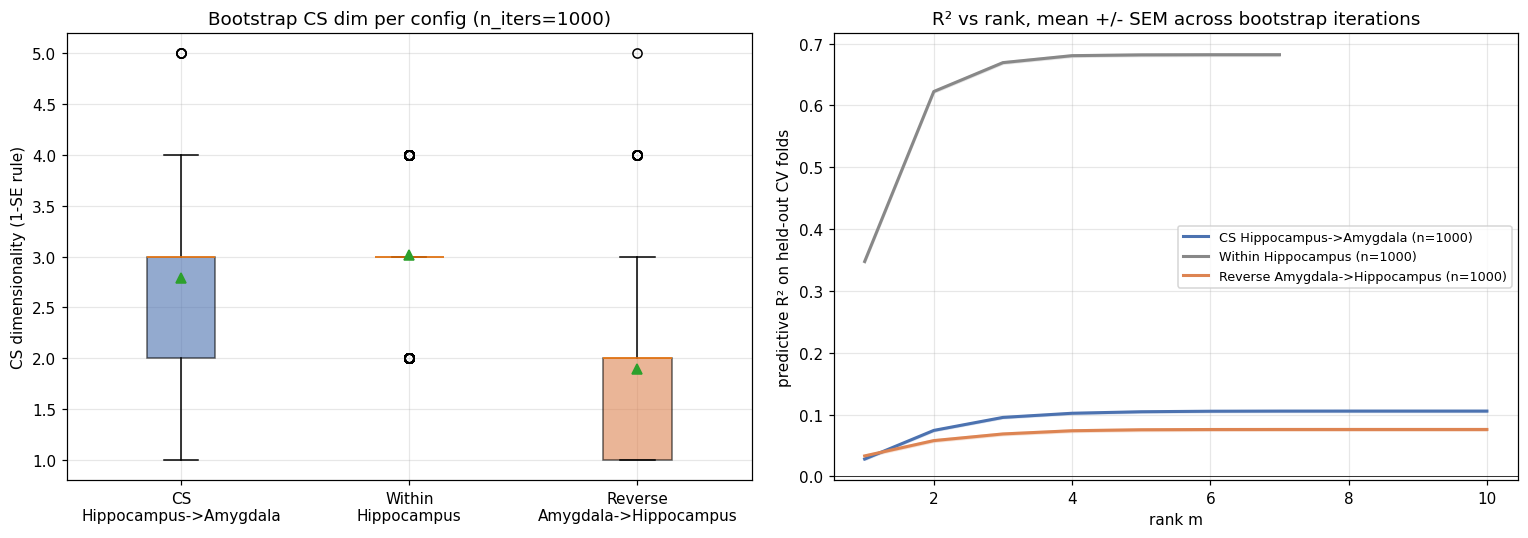


--- Within-pilot paired comparisons ---
  CS Hippocampus->Amygdala  vs  Within Hippocampus: n_pairs=1000, W=41653.0, p=1.873e-16; medians 3.0 vs 3.0
  CS Hippocampus->Amygdala  vs  Reverse Amygdala->Hippocampus: n_pairs=1000, W=21831.0, p=1.307e-96; medians 3.0 vs 2.0


In [138]:
# --- Plot RRR results: dim distributions + R² vs rank curves ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (a) CS dim distribution per configuration
ax = axes[0]
configs = [
    (f"CS\n{CONFIG['source_region']}->{CONFIG['target_region']}", res_cs, '#4C72B0'),
    (f"Within\n{CONFIG['source_region']}", res_within, '#888888'),
    (f"Reverse\n{CONFIG['target_region']}->{CONFIG['source_region']}", res_reverse, '#DD8452'),
]
data = [r['cs_dim'][~np.isnan(r['cs_dim'])] for _, r, _ in configs]
labels = [name for name, _, _ in configs]
parts = ax.boxplot(data, labels=labels, showmeans=True, patch_artist=True)
for patch, (_, _, color) in zip(parts['boxes'], configs):
    patch.set_facecolor(color); patch.set_alpha(0.6)
ax.set_ylabel('CS dimensionality (1-SE rule)')
ax.set_title(f'Bootstrap CS dim per config (n_iters={RRR_N_ITERS})')

# (b) R² vs rank curves: mean ± SEM across iterations
ax = axes[1]
for name, r, color in configs:
    curves = r['r2_curves']
    rg = r['rank_grid']
    valid = ~np.isnan(curves).all(axis=1)
    if not valid.any():
        continue
    m = np.nanmean(curves[valid], axis=0)
    sem = np.nanstd(curves[valid], axis=0) / np.sqrt(valid.sum())
    label_short = name.replace('\n', ' ')
    ax.plot(rg, m, color=color, lw=2, label=f'{label_short} (n={valid.sum()})')
    ax.fill_between(rg, m - sem, m + sem, color=color, alpha=0.2)
ax.set_xlabel('rank m')
ax.set_ylabel('predictive R² on held-out CV folds')
ax.set_title('R² vs rank, mean +/- SEM across bootstrap iterations')
ax.axhline(0, color='k', lw=0.5)
ax.legend(fontsize='small')

plt.tight_layout(); plt.show()

# Paired comparison: CS vs within-source dim, CS vs reverse dim (per-iteration paired)
print("\n--- Within-pilot paired comparisons ---")
for name_a, ra, name_b, rb in [
    (f"CS {CONFIG['source_region']}->{CONFIG['target_region']}", res_cs, f"Within {CONFIG['source_region']}", res_within),
    (f"CS {CONFIG['source_region']}->{CONFIG['target_region']}", res_cs, f"Reverse {CONFIG['target_region']}->{CONFIG['source_region']}", res_reverse),
]:
    a = ra['cs_dim']; b = rb['cs_dim']
    mask = ~(np.isnan(a) | np.isnan(b))
    if mask.sum() < 8:
        print(f"  [skip] {name_a} vs {name_b}: too few paired iters ({mask.sum()})")
        continue
    stat, p = scistats.wilcoxon(a[mask], b[mask], zero_method='wilcox')
    print(f"  {name_a}  vs  {name_b}: "
          f"n_pairs={mask.sum()}, W={stat:.1f}, p={p:.4g}; "
          f"medians {np.median(a[mask]):.1f} vs {np.median(b[mask]):.1f}")


In [139]:
# --- Section 7 on the DELAY epoch — LOAD 1 ONLY, grouped by 1st-stim category ---
# The delay-cat run is restricted to load-1 trials so that the maintenance period
# corresponds to a single stim of a single category. In load-3 trials the delay holds
# three stims of (potentially) different categories — '1st-stim cat' is noisy as a
# label for that activity, so we exclude them here.
# (For load-driven delay analysis regardless of category, see the delay-load cells below.)

meta_d = pilot_epoched_delay['meta'].reset_index(drop=True)
load1_mask_d = (meta_d['loads'] == 1).to_numpy()
print(f"Delay trials total: {len(meta_d)};  load==1 retained: {load1_mask_d.sum()};  load==3 dropped: {(~load1_mask_d).sum()}")

# Subset both region tensors and the meta to load-1 trials
src_tensor_d_l1 = src_tensor_d[load1_mask_d]
tgt_tensor_d_l1 = tgt_tensor_d[load1_mask_d]
meta_d_l1 = meta_d.loc[load1_mask_d].reset_index(drop=True)

trial_groups_d = get_trial_groups(
    meta_d_l1,
    mode=CONFIG['trial_grouping'],
    keep=CONFIG['category_keep'],
)
print(trial_groups_d['summary'])

X_hipp_d = build_rrr_data_matrix(src_tensor_d_l1, trial_groups_d['groups'], RRR_DOWNSAMPLE, RRR_AGGREGATE)
Y_amyg_d = build_rrr_data_matrix(tgt_tensor_d_l1, trial_groups_d['groups'], RRR_DOWNSAMPLE, RRR_AGGREGATE)
print(f"\n[delay-cat-load1] X_src: {X_hipp_d.shape}, Y_tgt: {Y_amyg_d.shape}")

n_chan_within_d = min(RRR_N_CHANS, X_hipp_d.shape[1] // 2)
rank_grid_within_d = np.arange(1, n_chan_within_d + 1)

import time

print(f"\n[delay-cat-load1 CS] {CONFIG['source_region']} -> {CONFIG['target_region']}")
t0 = time.time()
rng_cs_d = np.random.default_rng(CONFIG['random_seed'] + 20)
res_cs_d = bootstrap_rrr(
    X_hipp_d, Y_amyg_d, RRR_N_CHANS, RRR_N_CHANS, RRR_N_ITERS,
    RRR_ALPHA_GRID, rank_grid_cs, RRR_N_FOLDS, rng_cs_d,
    sampling='replace',
)
print(f"  -> {time.time() - t0:.1f}s")

print(f"\n[delay-cat-load1 Within] {CONFIG['source_region']} -> {CONFIG['source_region']} (disjoint halves)")
t0 = time.time()
rng_w_d = np.random.default_rng(CONFIG['random_seed'] + 21)
res_within_d = bootstrap_rrr(
    X_hipp_d, X_hipp_d, n_chan_within_d, n_chan_within_d, RRR_N_ITERS,
    RRR_ALPHA_GRID, rank_grid_within_d, RRR_N_FOLDS, rng_w_d,
    sampling='disjoint',
)
print(f"  -> {time.time() - t0:.1f}s")

print(f"\n[delay-cat-load1 Reverse] {CONFIG['target_region']} -> {CONFIG['source_region']}")
t0 = time.time()
rng_r_d = np.random.default_rng(CONFIG['random_seed'] + 22)
res_reverse_d = bootstrap_rrr(
    Y_amyg_d, X_hipp_d, RRR_N_CHANS, RRR_N_CHANS, RRR_N_ITERS,
    RRR_ALPHA_GRID, rank_grid_cs, RRR_N_FOLDS, rng_r_d,
    sampling='replace',
)
print(f"  -> {time.time() - t0:.1f}s")

print("\n--- Section 7 RRR DELAY-cat-load1 summary ---")
print(_rrr_summary(f"CS {CONFIG['source_region']}->{CONFIG['target_region']} (delay-cat-load1)", res_cs_d))
print(_rrr_summary(f"Within {CONFIG['source_region']} (delay-cat-load1)", res_within_d))
print(_rrr_summary(f"Reverse {CONFIG['target_region']}->{CONFIG['source_region']} (delay-cat-load1)", res_reverse_d))


Delay trials total: 132;  load==1 retained: 67;  load==3 dropped: 65
=== Trial Grouping by 1st-Stim Category ===
Total trials: 67
Number of groups: 5

  cat 1: 14 trials
  cat 2: 14 trials
  cat 3: 13 trials
  cat 4: 13 trials
  cat 5: 13 trials

[delay-cat-load1] X_src: (625, 14), Y_tgt: (625, 15)

[delay-cat-load1 CS] Hippocampus -> Amygdala
  iter 25/1000: cs_dim=2.0, peak R²=0.023
  iter 50/1000: cs_dim=2.0, peak R²=-0.019
  iter 75/1000: cs_dim=2.0, peak R²=-0.043
  iter 100/1000: cs_dim=2.0, peak R²=0.006
  iter 125/1000: cs_dim=2.0, peak R²=0.063
  iter 150/1000: cs_dim=3.0, peak R²=0.002
  iter 175/1000: cs_dim=3.0, peak R²=-0.007
  iter 200/1000: cs_dim=2.0, peak R²=0.007
  iter 225/1000: cs_dim=2.0, peak R²=-0.054
  iter 250/1000: cs_dim=2.0, peak R²=-0.004
  iter 275/1000: cs_dim=2.0, peak R²=-0.011
  iter 300/1000: cs_dim=2.0, peak R²=-0.036
  iter 325/1000: cs_dim=2.0, peak R²=-0.026
  iter 350/1000: cs_dim=2.0, peak R²=-0.065
  iter 375/1000: cs_dim=1.0, peak R²=-0.205
  

C:\Users\zhuj3\AppData\Local\Temp\ipykernel_26888\4065742704.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  parts = ax.boxplot(data, labels=labels, showmeans=True, patch_artist=True)
C:\Users\zhuj3\AppData\Local\Temp\ipykernel_26888\4065742704.py:56: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  parts = ax.boxplot(data_paired, positions=positions, labels=labels_paired,
C:\Users\zhuj3\AppData\Local\Temp\ipykernel_26888\4065742704.py:70: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  parts = ax.boxplot(data_paired_r2, positions=positions, labels=labels_paired,


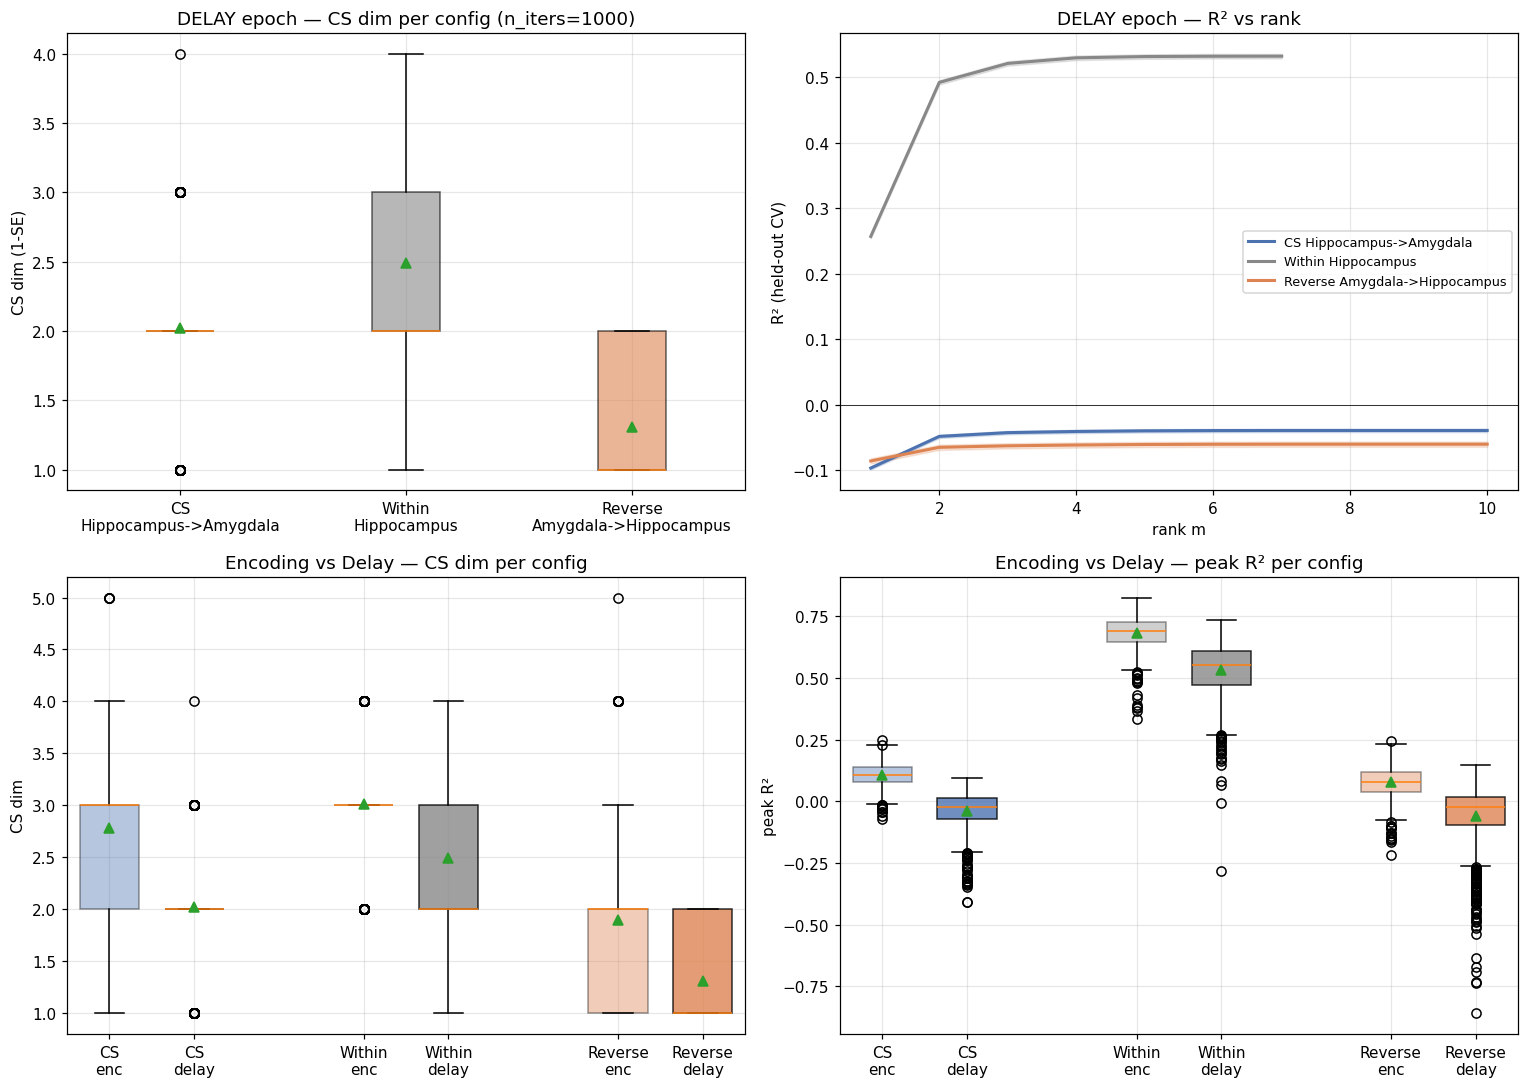


--- Delay-epoch within-pilot paired comparisons ---
  CS (delay) vs Within (delay): n_pairs=1000, W=13864.0, p=1.187e-68; medians 2.0 vs 2.0
  CS (delay) vs Reverse (delay): n_pairs=1000, W=8874.0, p=7.085e-119; medians 2.0 vs 1.0
  CS (encoding) vs CS (delay): n_pairs=1000, W=13447.0, p=1.952e-104; medians 3.0 vs 2.0


In [140]:
# --- Plot DELAY-epoch RRR + side-by-side encoding-vs-delay comparison ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Row 0 = delay alone, Row 1 = encoding vs delay (paired)
configs_delay = [
    (f"CS\n{CONFIG['source_region']}->{CONFIG['target_region']}", res_cs_d, '#4C72B0'),
    (f"Within\n{CONFIG['source_region']}", res_within_d, '#888888'),
    (f"Reverse\n{CONFIG['target_region']}->{CONFIG['source_region']}", res_reverse_d, '#DD8452'),
]

# (0,0): CS dim distribution per config (delay)
ax = axes[0, 0]
data = [r['cs_dim'][~np.isnan(r['cs_dim'])] for _, r, _ in configs_delay]
labels = [name for name, _, _ in configs_delay]
parts = ax.boxplot(data, labels=labels, showmeans=True, patch_artist=True)
for patch, (_, _, color) in zip(parts['boxes'], configs_delay):
    patch.set_facecolor(color); patch.set_alpha(0.6)
ax.set_ylabel('CS dim (1-SE)')
ax.set_title(f'DELAY epoch — CS dim per config (n_iters={RRR_N_ITERS})')

# (0,1): R² vs rank (delay)
ax = axes[0, 1]
for name, r, color in configs_delay:
    curves = r['r2_curves']; rg = r['rank_grid']
    valid = ~np.isnan(curves).all(axis=1)
    if not valid.any():
        continue
    m = np.nanmean(curves[valid], axis=0)
    sem = np.nanstd(curves[valid], axis=0) / np.sqrt(valid.sum())
    ax.plot(rg, m, color=color, lw=2, label=name.replace('\n', ' '))
    ax.fill_between(rg, m - sem, m + sem, color=color, alpha=0.2)
ax.set_xlabel('rank m'); ax.set_ylabel('R² (held-out CV)')
ax.set_title('DELAY epoch — R² vs rank')
ax.axhline(0, color='k', lw=0.5)
ax.legend(fontsize='small')

# (1,0): encoding vs delay CS dim, paired-iteration boxplot
ax = axes[1, 0]
pairs = [
    ('CS', res_cs, res_cs_d, '#4C72B0'),
    ('Within', res_within, res_within_d, '#888888'),
    ('Reverse', res_reverse, res_reverse_d, '#DD8452'),
]
positions = []
data_paired = []
labels_paired = []
colors_paired = []
for i, (name, e, d, color) in enumerate(pairs):
    positions.extend([i * 3 + 1, i * 3 + 2])
    data_paired.extend([
        e['cs_dim'][~np.isnan(e['cs_dim'])],
        d['cs_dim'][~np.isnan(d['cs_dim'])],
    ])
    labels_paired.extend([f'{name}\nenc', f'{name}\ndelay'])
    colors_paired.extend([color, color])
parts = ax.boxplot(data_paired, positions=positions, labels=labels_paired,
                   showmeans=True, patch_artist=True, widths=0.7)
for patch, color, i in zip(parts['boxes'], colors_paired, range(len(parts['boxes']))):
    patch.set_facecolor(color)
    patch.set_alpha(0.4 if i % 2 == 0 else 0.8)  # darker = delay
ax.set_ylabel('CS dim')
ax.set_title('Encoding vs Delay — CS dim per config')

# (1,1): encoding vs delay peak R²
ax = axes[1, 1]
data_paired_r2 = []
for _, e, d, _ in pairs:
    data_paired_r2.append(e['best_r2'][~np.isnan(e['best_r2'])])
    data_paired_r2.append(d['best_r2'][~np.isnan(d['best_r2'])])
parts = ax.boxplot(data_paired_r2, positions=positions, labels=labels_paired,
                   showmeans=True, patch_artist=True, widths=0.7)
for patch, color, i in zip(parts['boxes'], colors_paired, range(len(parts['boxes']))):
    patch.set_facecolor(color)
    patch.set_alpha(0.4 if i % 2 == 0 else 0.8)
ax.set_ylabel('peak R²')
ax.set_title('Encoding vs Delay — peak R² per config')

plt.tight_layout(); plt.show()

# Within-pilot paired tests for delay epoch
print("\n--- Delay-epoch within-pilot paired comparisons ---")
for name_a, ra, name_b, rb in [
    (f"CS (delay)", res_cs_d, f"Within (delay)", res_within_d),
    (f"CS (delay)", res_cs_d, f"Reverse (delay)", res_reverse_d),
    (f"CS (encoding)", res_cs, f"CS (delay)", res_cs_d),
]:
    a = ra['cs_dim']; b = rb['cs_dim']
    mask = ~(np.isnan(a) | np.isnan(b))
    if mask.sum() < 8:
        print(f"  [skip] {name_a} vs {name_b}: too few paired iters ({mask.sum()})")
        continue
    stat, p = scistats.wilcoxon(a[mask], b[mask], zero_method='wilcox')
    print(f"  {name_a} vs {name_b}: n_pairs={mask.sum()}, W={stat:.1f}, p={p:.4g}; "
          f"medians {np.median(a[mask]):.1f} vs {np.median(b[mask]):.1f}")


In [141]:
# --- Section 7 on the DELAY epoch — grouped by LOAD (1 vs 3), all trials ---
# Tests load-driven communication during maintenance, regardless of stim category.
# Uses the same delay-locked tensors (src_tensor_d, tgt_tensor_d) but groups via
# the 'load' dispatcher branch (2 groups: Load 1, Load 3).

trial_groups_d_load = get_trial_groups(
    pilot_epoched_delay['meta'],
    mode='load',
    keep=CONFIG['category_keep'],   # ignored when mode='load'
)
print(trial_groups_d_load['summary'])

X_hipp_d_load = build_rrr_data_matrix(src_tensor_d, trial_groups_d_load['groups'], RRR_DOWNSAMPLE, RRR_AGGREGATE)
Y_amyg_d_load = build_rrr_data_matrix(tgt_tensor_d, trial_groups_d_load['groups'], RRR_DOWNSAMPLE, RRR_AGGREGATE)
print(f"\n[delay-load] X_src: {X_hipp_d_load.shape}, Y_tgt: {Y_amyg_d_load.shape}")

n_chan_within_d_load = min(RRR_N_CHANS, X_hipp_d_load.shape[1] // 2)
rank_grid_within_d_load = np.arange(1, n_chan_within_d_load + 1)

import time

print(f"\n[delay-load CS] {CONFIG['source_region']} -> {CONFIG['target_region']}")
t0 = time.time()
rng_cs_dl = np.random.default_rng(CONFIG['random_seed'] + 30)
res_cs_d_load = bootstrap_rrr(
    X_hipp_d_load, Y_amyg_d_load, RRR_N_CHANS, RRR_N_CHANS, RRR_N_ITERS,
    RRR_ALPHA_GRID, rank_grid_cs, RRR_N_FOLDS, rng_cs_dl,
    sampling='replace',
)
print(f"  -> {time.time() - t0:.1f}s")

print(f"\n[delay-load Within] {CONFIG['source_region']} -> {CONFIG['source_region']} (disjoint halves)")
t0 = time.time()
rng_w_dl = np.random.default_rng(CONFIG['random_seed'] + 31)
res_within_d_load = bootstrap_rrr(
    X_hipp_d_load, X_hipp_d_load, n_chan_within_d_load, n_chan_within_d_load, RRR_N_ITERS,
    RRR_ALPHA_GRID, rank_grid_within_d_load, RRR_N_FOLDS, rng_w_dl,
    sampling='disjoint',
)
print(f"  -> {time.time() - t0:.1f}s")

print(f"\n[delay-load Reverse] {CONFIG['target_region']} -> {CONFIG['source_region']}")
t0 = time.time()
rng_r_dl = np.random.default_rng(CONFIG['random_seed'] + 32)
res_reverse_d_load = bootstrap_rrr(
    Y_amyg_d_load, X_hipp_d_load, RRR_N_CHANS, RRR_N_CHANS, RRR_N_ITERS,
    RRR_ALPHA_GRID, rank_grid_cs, RRR_N_FOLDS, rng_r_dl,
    sampling='replace',
)
print(f"  -> {time.time() - t0:.1f}s")

print("\n--- Section 7 RRR DELAY-load summary ---")
print(_rrr_summary(f"CS {CONFIG['source_region']}->{CONFIG['target_region']} (delay-load)", res_cs_d_load))
print(_rrr_summary(f"Within {CONFIG['source_region']} (delay-load)", res_within_d_load))
print(_rrr_summary(f"Reverse {CONFIG['target_region']}->{CONFIG['source_region']} (delay-load)", res_reverse_d_load))


=== Trial Grouping by Memory Load ===
Total trials: 132
Number of groups: 2

  Load 1: 67 trials
  Load 3: 65 trials

[delay-load] X_src: (250, 14), Y_tgt: (250, 15)

[delay-load CS] Hippocampus -> Amygdala
  iter 25/1000: cs_dim=3.0, peak R²=-0.021
  iter 50/1000: cs_dim=2.0, peak R²=-0.030
  iter 75/1000: cs_dim=2.0, peak R²=0.055
  iter 100/1000: cs_dim=3.0, peak R²=0.020
  iter 125/1000: cs_dim=2.0, peak R²=0.051
  iter 150/1000: cs_dim=2.0, peak R²=-0.017
  iter 175/1000: cs_dim=2.0, peak R²=0.045
  iter 200/1000: cs_dim=2.0, peak R²=0.005
  iter 225/1000: cs_dim=3.0, peak R²=-0.026
  iter 250/1000: cs_dim=1.0, peak R²=-0.048
  iter 275/1000: cs_dim=3.0, peak R²=0.012
  iter 300/1000: cs_dim=2.0, peak R²=-0.027
  iter 325/1000: cs_dim=2.0, peak R²=-0.029
  iter 350/1000: cs_dim=3.0, peak R²=-0.009
  iter 375/1000: cs_dim=2.0, peak R²=-0.060
  iter 400/1000: cs_dim=3.0, peak R²=-0.055
  iter 425/1000: cs_dim=2.0, peak R²=-0.092
  iter 450/1000: cs_dim=2.0, peak R²=0.078
  iter 475/

C:\Users\zhuj3\AppData\Local\Temp\ipykernel_26888\1321637660.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  parts = ax.boxplot(data, labels=labels, showmeans=True, patch_artist=True)
C:\Users\zhuj3\AppData\Local\Temp\ipykernel_26888\1321637660.py:55: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  parts = ax.boxplot(data_paired, positions=positions, labels=labels_paired,
C:\Users\zhuj3\AppData\Local\Temp\ipykernel_26888\1321637660.py:69: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  parts = ax.boxplot(data_paired_r2, positions=positions, labels=labels_paired,


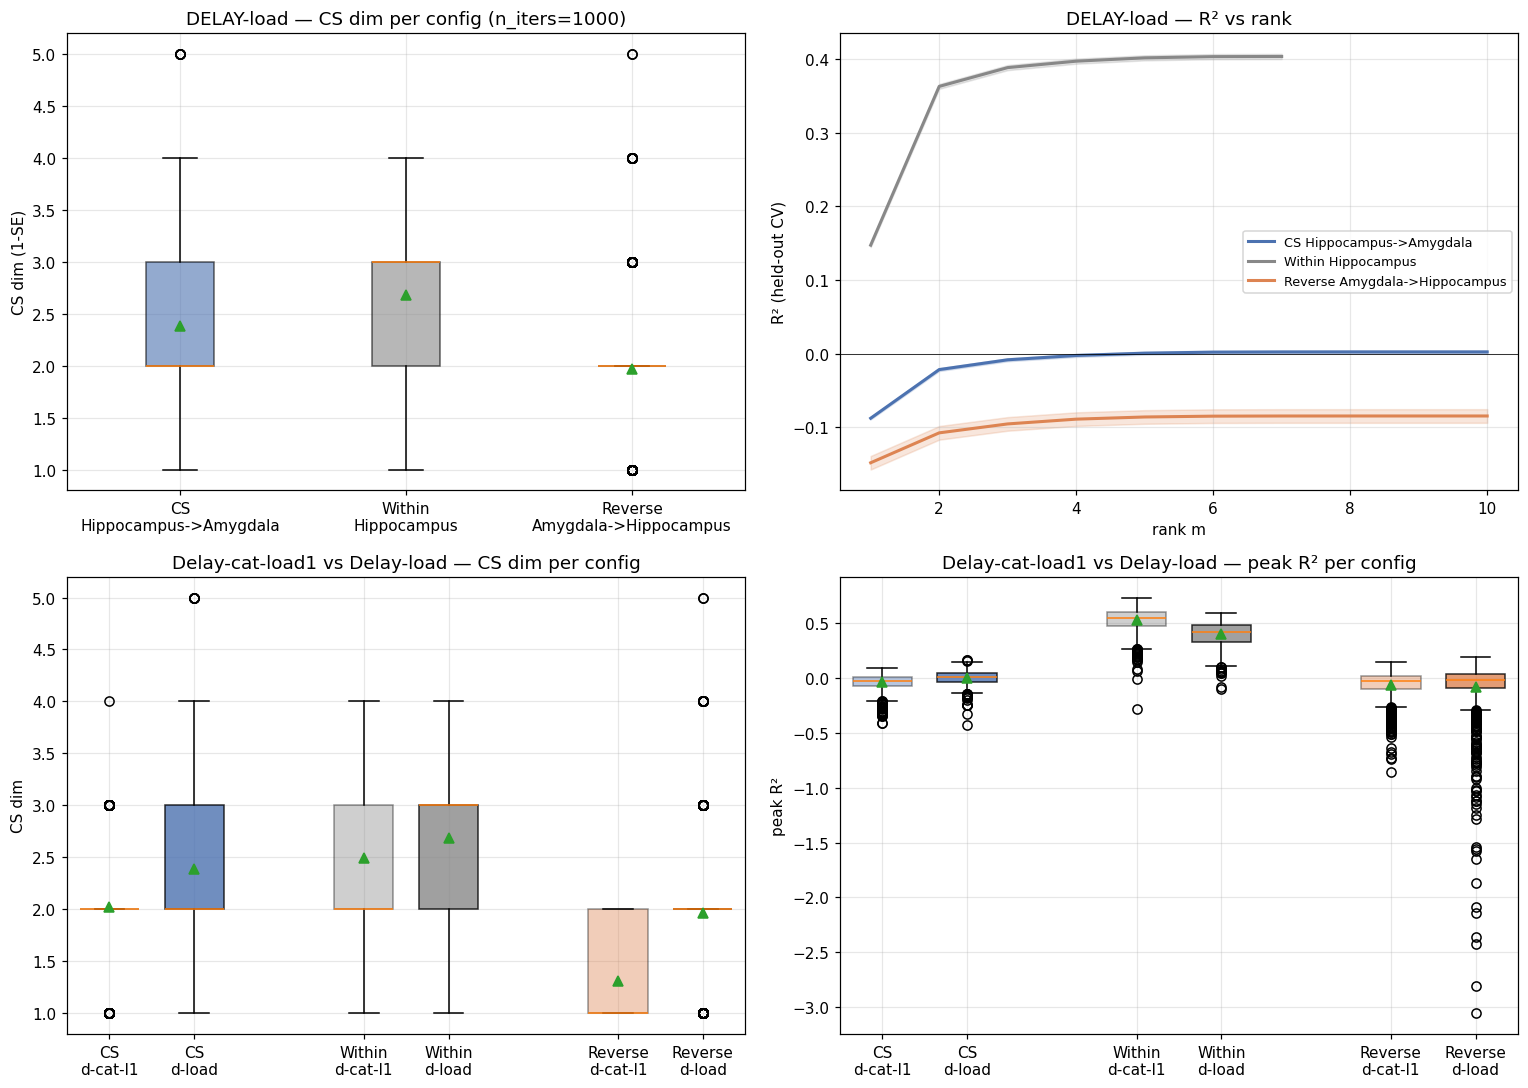


--- Delay-load within-pilot paired comparisons ---
  CS (delay-load) vs Within (delay-load): n_pairs=1000, W=49834.5, p=4.263e-26; medians 2.0 vs 3.0
  CS (delay-load) vs Reverse (delay-load): n_pairs=1000, W=38587.5, p=5.633e-36; medians 2.0 vs 2.0
  CS (delay-cat-load1) vs CS (delay-load): n_pairs=1000, W=21392.5, p=3.35e-39; medians 2.0 vs 2.0
  CS (encoding) vs CS (delay-load): n_pairs=1000, W=46969.5, p=5.421e-36; medians 3.0 vs 2.0


In [142]:
# --- Plot delay-load RRR results + delay-cat-load1 vs delay-load comparison ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

configs_dload = [
    (f"CS\n{CONFIG['source_region']}->{CONFIG['target_region']}", res_cs_d_load, '#4C72B0'),
    (f"Within\n{CONFIG['source_region']}", res_within_d_load, '#888888'),
    (f"Reverse\n{CONFIG['target_region']}->{CONFIG['source_region']}", res_reverse_d_load, '#DD8452'),
]

# (0,0): delay-load CS dim per config
ax = axes[0, 0]
data = [r['cs_dim'][~np.isnan(r['cs_dim'])] for _, r, _ in configs_dload]
labels = [name for name, _, _ in configs_dload]
parts = ax.boxplot(data, labels=labels, showmeans=True, patch_artist=True)
for patch, (_, _, color) in zip(parts['boxes'], configs_dload):
    patch.set_facecolor(color); patch.set_alpha(0.6)
ax.set_ylabel('CS dim (1-SE)')
ax.set_title(f'DELAY-load — CS dim per config (n_iters={RRR_N_ITERS})')

# (0,1): delay-load R² vs rank
ax = axes[0, 1]
for name, r, color in configs_dload:
    curves = r['r2_curves']; rg = r['rank_grid']
    valid = ~np.isnan(curves).all(axis=1)
    if not valid.any():
        continue
    m = np.nanmean(curves[valid], axis=0)
    sem = np.nanstd(curves[valid], axis=0) / np.sqrt(valid.sum())
    ax.plot(rg, m, color=color, lw=2, label=name.replace('\n', ' '))
    ax.fill_between(rg, m - sem, m + sem, color=color, alpha=0.2)
ax.set_xlabel('rank m'); ax.set_ylabel('R² (held-out CV)')
ax.set_title('DELAY-load — R² vs rank')
ax.axhline(0, color='k', lw=0.5)
ax.legend(fontsize='small')

# (1,0): delay-cat-load1 vs delay-load CS dim, paired-iter boxplot
ax = axes[1, 0]
pairs = [
    ('CS', res_cs_d, res_cs_d_load, '#4C72B0'),
    ('Within', res_within_d, res_within_d_load, '#888888'),
    ('Reverse', res_reverse_d, res_reverse_d_load, '#DD8452'),
]
positions = []
data_paired = []
labels_paired = []
colors_paired = []
for i, (name, dcat, dload, color) in enumerate(pairs):
    positions.extend([i * 3 + 1, i * 3 + 2])
    data_paired.extend([
        dcat['cs_dim'][~np.isnan(dcat['cs_dim'])],
        dload['cs_dim'][~np.isnan(dload['cs_dim'])],
    ])
    labels_paired.extend([f'{name}\nd-cat-l1', f'{name}\nd-load'])
    colors_paired.extend([color, color])
parts = ax.boxplot(data_paired, positions=positions, labels=labels_paired,
                   showmeans=True, patch_artist=True, widths=0.7)
for patch, color, i in zip(parts['boxes'], colors_paired, range(len(parts['boxes']))):
    patch.set_facecolor(color)
    patch.set_alpha(0.4 if i % 2 == 0 else 0.8)
ax.set_ylabel('CS dim')
ax.set_title('Delay-cat-load1 vs Delay-load — CS dim per config')

# (1,1): delay-cat-load1 vs delay-load peak R²
ax = axes[1, 1]
data_paired_r2 = []
for _, dcat, dload, _ in pairs:
    data_paired_r2.append(dcat['best_r2'][~np.isnan(dcat['best_r2'])])
    data_paired_r2.append(dload['best_r2'][~np.isnan(dload['best_r2'])])
parts = ax.boxplot(data_paired_r2, positions=positions, labels=labels_paired,
                   showmeans=True, patch_artist=True, widths=0.7)
for patch, color, i in zip(parts['boxes'], colors_paired, range(len(parts['boxes']))):
    patch.set_facecolor(color)
    patch.set_alpha(0.4 if i % 2 == 0 else 0.8)
ax.set_ylabel('peak R²')
ax.set_title('Delay-cat-load1 vs Delay-load — peak R² per config')

plt.tight_layout(); plt.show()

# Within-pilot paired tests for delay-load epoch
print("\n--- Delay-load within-pilot paired comparisons ---")
for name_a, ra, name_b, rb in [
    ("CS (delay-load)", res_cs_d_load, "Within (delay-load)", res_within_d_load),
    ("CS (delay-load)", res_cs_d_load, "Reverse (delay-load)", res_reverse_d_load),
    ("CS (delay-cat-load1)", res_cs_d, "CS (delay-load)", res_cs_d_load),
    ("CS (encoding)", res_cs, "CS (delay-load)", res_cs_d_load),
]:
    a = ra['cs_dim']; b = rb['cs_dim']
    mask = ~(np.isnan(a) | np.isnan(b))
    if mask.sum() < 8:
        print(f"  [skip] {name_a} vs {name_b}: too few paired iters ({mask.sum()})")
        continue
    stat, p = scistats.wilcoxon(a[mask], b[mask], zero_method='wilcox')
    print(f"  {name_a} vs {name_b}: n_pairs={mask.sum()}, W={stat:.1f}, p={p:.4g}; "
          f"medians {np.median(a[mask]):.1f} vs {np.median(b[mask]):.1f}")


In [143]:
# --- All-sessions RRR group analysis ---
# Slow: ~1-3 min per session at RRR_N_ITERS=100, ~10-30 min at 1000.
# Toggle RUN_ALL_SESSIONS_RRR = True to actually execute.

RUN_ALL_SESSIONS_RRR = False
ALL_RRR_N_ITERS = 100   # bump to 1000 for the final group analysis

if RUN_ALL_SESSIONS_RRR:
    SRC_REGION = CONFIG['source_region']
    TGT_REGION = CONFIG['target_region']
    rrr_rows = []
    for sess_i, sess in passing.reset_index(drop=True).iterrows():
        print(f"\n=== [{sess_i+1}/{len(passing)}] {sess['subject']}/{sess['session']} ===")
        try:
            d = load_nwb_file(sess['filepath'])
            clean_lfp, fs_s, edf_s, _ = preprocess_session_lfp(d, CONFIG, verbose=False)
            region_chans_s, _ = extract_region_channels(edf_s)
            src_chans_s = region_chans_s[SRC_REGION]
            tgt_chans_s = region_chans_s[TGT_REGION]
            if len(src_chans_s) < 4 or len(tgt_chans_s) < 4:
                print(f"  [skip] insufficient channels (src={len(src_chans_s)}, tgt={len(tgt_chans_s)})")
                continue
            all_chans = src_chans_s + tgt_chans_s
            rng_s = np.random.default_rng(CONFIG['random_seed'] + 100 + sess_i)
            hfa_s, _ = extract_hfa_session(clean_lfp, fs_s, all_chans, d['trials'], CONFIG, rng=rng_s)
            ep_s = build_trial_tensors(
                hfa=hfa_s, lfp_clean=clean_lfp, fs=fs_s,
                src_chans=src_chans_s, tgt_chans=tgt_chans_s, hfa_chan_order=all_chans,
                trial_table=d['trials'], cfg=CONFIG,
            )
            grp_s = get_trial_groups(ep_s['meta'], mode=CONFIG['trial_grouping'], keep=CONFIG['category_keep'])
            X_s = build_rrr_data_matrix(ep_s[SRC_REGION], grp_s['groups'], RRR_DOWNSAMPLE, RRR_AGGREGATE)
            Y_s = build_rrr_data_matrix(ep_s[TGT_REGION], grp_s['groups'], RRR_DOWNSAMPLE, RRR_AGGREGATE)
            n_chan_w = min(RRR_N_CHANS, X_s.shape[1] // 2)
            rg_cs = np.arange(1, RRR_N_CHANS + 1)
            rg_w  = np.arange(1, n_chan_w + 1)

            cs   = bootstrap_rrr(X_s, Y_s, RRR_N_CHANS, RRR_N_CHANS, ALL_RRR_N_ITERS,
                                 RRR_ALPHA_GRID, rg_cs, RRR_N_FOLDS, rng_s, sampling='replace', verbose=False)
            wsr  = bootstrap_rrr(X_s, X_s, n_chan_w, n_chan_w, ALL_RRR_N_ITERS,
                                 RRR_ALPHA_GRID, rg_w, RRR_N_FOLDS, rng_s, sampling='disjoint', verbose=False)
            rev  = bootstrap_rrr(Y_s, X_s, RRR_N_CHANS, RRR_N_CHANS, ALL_RRR_N_ITERS,
                                 RRR_ALPHA_GRID, rg_cs, RRR_N_FOLDS, rng_s, sampling='replace', verbose=False)

            row = {
                'subject': sess['subject'],
                'session': sess['session'],
                'cs_dim_cs':       float(np.nanmean(cs['cs_dim'])),
                'cs_dim_within':   float(np.nanmean(wsr['cs_dim'])),
                'cs_dim_reverse':  float(np.nanmean(rev['cs_dim'])),
                'r2_cs':       float(np.nanmean(cs['best_r2'])),
                'r2_within':   float(np.nanmean(wsr['best_r2'])),
                'r2_reverse':  float(np.nanmean(rev['best_r2'])),
                'n_chan_src': X_s.shape[1],
                'n_chan_tgt': Y_s.shape[1],
            }
            rrr_rows.append(row)
            print(f"  cs={row['cs_dim_cs']:.2f}, within={row['cs_dim_within']:.2f}, "
                  f"reverse={row['cs_dim_reverse']:.2f}; "
                  f"R²: cs={row['r2_cs']:.3f}, within={row['r2_within']:.3f}, reverse={row['r2_reverse']:.3f}")
            d['io'].close()
        except Exception as e:
            print(f"  [error] {e}")
            continue

    rrr_group = pd.DataFrame(rrr_rows)
    rrr_group.to_csv(OUT_DIR / 'group_rrr.csv', index=False)
    print(f"\nSaved {len(rrr_group)} sessions -> {OUT_DIR / 'group_rrr.csv'}")
    print(rrr_group.describe().T[['mean', 'std', 'min', '50%', 'max']])

    # Group-level paired tests
    paired = rrr_group.dropna(subset=['cs_dim_cs', 'cs_dim_within', 'cs_dim_reverse'])
    if len(paired) >= 5:
        for col_a, col_b in [('cs_dim_cs', 'cs_dim_within'),
                             ('cs_dim_cs', 'cs_dim_reverse'),
                             ('r2_cs', 'r2_within')]:
            stat, p = scistats.wilcoxon(paired[col_a], paired[col_b], zero_method='wilcox')
            print(f"  {col_a} vs {col_b}: n={len(paired)}, W={stat:.1f}, p={p:.4g}")

    # Boxplot of session-mean cs dim across the three configs
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    ax = axes[0]
    parts = ax.boxplot(
        [paired['cs_dim_cs'], paired['cs_dim_within'], paired['cs_dim_reverse']],
        labels=['CS', 'Within', 'Reverse'], showmeans=True, patch_artist=True,
    )
    for patch, color in zip(parts['boxes'], ['#4C72B0', '#888888', '#DD8452']):
        patch.set_facecolor(color); patch.set_alpha(0.6)
    for _, r in paired.iterrows():
        ax.plot([1, 2, 3], [r['cs_dim_cs'], r['cs_dim_within'], r['cs_dim_reverse']],
                'k-', alpha=0.2, lw=0.6)
    ax.set_ylabel('Session-mean CS dim')
    ax.set_title(f'Group-level CS dim (n={len(paired)} sessions)')

    ax = axes[1]
    parts = ax.boxplot(
        [paired['r2_cs'], paired['r2_within'], paired['r2_reverse']],
        labels=['CS', 'Within', 'Reverse'], showmeans=True, patch_artist=True,
    )
    for patch, color in zip(parts['boxes'], ['#4C72B0', '#888888', '#DD8452']):
        patch.set_facecolor(color); patch.set_alpha(0.6)
    for _, r in paired.iterrows():
        ax.plot([1, 2, 3], [r['r2_cs'], r['r2_within'], r['r2_reverse']],
                'k-', alpha=0.2, lw=0.6)
    ax.set_ylabel('Session-mean peak R²')
    ax.set_title(f'Group-level peak R² (n={len(paired)} sessions)')

    plt.tight_layout(); plt.show()
else:
    print("RUN_ALL_SESSIONS_RRR = False - skipping group RRR loop.")
    print("Set RUN_ALL_SESSIONS_RRR = True (and optionally ALL_RRR_N_ITERS = 1000) to run it.")


RUN_ALL_SESSIONS_RRR = False - skipping group RRR loop.
Set RUN_ALL_SESSIONS_RRR = True (and optionally ALL_RRR_N_ITERS = 1000) to run it.


## 8. Group-Level CSA Statistics

- Paired test: hipp→amyg CS dim vs within-hipp dim across sessions.
- Paired test: predictive R² hipp→amyg vs within-hipp.
- Both directions of hipp/amyg.
- Plots: dim boxplots, R² vs rank curves with SE bands, full vs reduced model R².

In [144]:
# TODO Section 8: per-session aggregation + Wilcoxon paired tests
pass

## 9. Project Source onto CS, Extract Latent Dynamics

For each session, project hipp HFA onto the first CS dimension → 1D latent timeseries per trial. Condition-average per split (load 1 vs load 3 by default). Plot example sessions analogous to Binish Fig 4a.

In [145]:
# TODO Section 9: latent_per_trial = src_hfa @ V_CS[:, 0]
pass

## 10. Behavioral Correlation

Per session: peak latency of latent dynamics per condition, mean RT per condition.

Group: Spearman across sessions of (latency_diff, RT_diff) — Binish Fig 4b.

Single-trial: per-trial latent peak latency vs RT (Spearman). Compare to single-trial raw-HFA peak vs RT in hipp and amyg — Binish Fig 4c.

In [146]:
# TODO Section 10: latency = argmax over post-event window; spearmanr against RT
pass

## 11. Null Distributions

1. **Weight-shuffle null**: permute the RRR weights within session, regenerate latent, recompute behavioral correlation. 1000 perms.
2. **Cross-subject null**: pair source from subject A with target from subject B, recompute CS and behavioral correlation. 1000 perms.

Report observed correlation against both null distributions.

In [147]:
# TODO Section 11: weight-shuffle and cross-subject permutation
pass

## 12. Save Results

Per-session: CS dim, R² curves, RRR weights, latent dynamics, peak timings, correlation values.
Group-level: summary stats + figures. HDF5 (preferred) or pickle.

In [148]:
# TODO Section 12: write results to OUT_DIR / 'session_<id>.h5' and group_summary.h5
pass